Training samples : (60000, 28, 28)
Testing  samples : (10000, 28, 28)

After pre-processing:
x_train : (60000, 28, 28, 1)  y_train : (60000, 10)
x_test  : (10000, 28, 28, 1)  y_test  : (10000, 10)


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (AveragePooling2D)           │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (AveragePooling2D)           │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5 (Conv2D)                     │ (None, 1, 1, 120)      │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9367 - loss: 0.2114 - val_accuracy: 0.9748 - val_loss: 0.0860
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9773 - loss: 0.0734 - val_accuracy: 0.9828 - val_loss: 0.0594
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9837 - loss: 0.0507 - val_accuracy: 0.9812 - val_loss: 0.0604
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9845 - val_loss: 0.0578
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.9911 - loss: 0.0279 - val_accuracy: 0.9848 - val_loss: 0.0540
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9925 - loss: 0.0236 - val_accuracy: 0.9877 - val_loss: 0.0461
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9938 - loss: 0.0185 - val_accuracy: 0.9857 - val_loss: 0.0539
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9956 - loss: 0.0145 - 

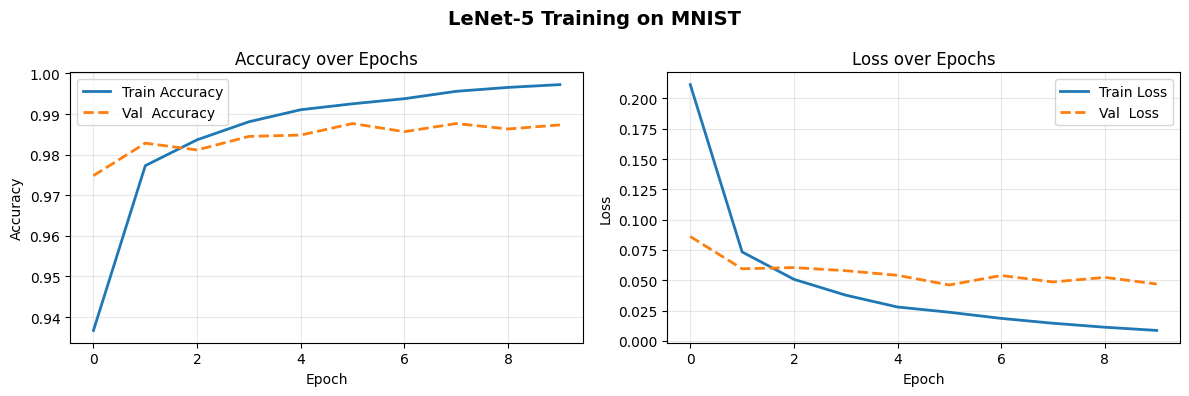

Training history plot saved.


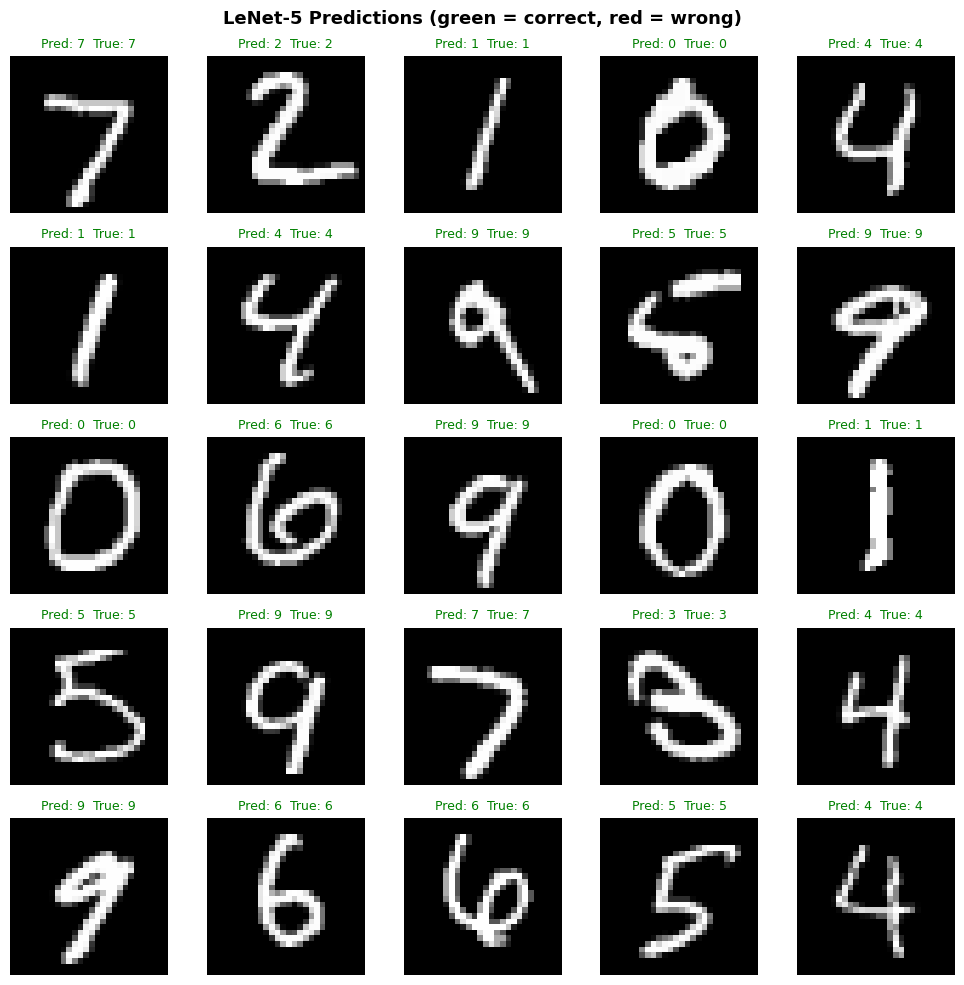

Prediction grid saved.


In [6]:
# =============================================================
#  LeNet-5 on MNIST  –  Keras 3 / TensorFlow 2.16+ compatible
# =============================================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, AveragePooling2D,
                                     Flatten, Dense, Input)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.utils import to_categorical

# ──────────────────────────────────────────────
# 1.  Load & inspect the MNIST dataset
# ──────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training samples :", x_train.shape)   # (60000, 28, 28)
print("Testing  samples :", x_test.shape)    # (10000, 28, 28)

# ──────────────────────────────────────────────
# 2.  Pre-processing
# ──────────────────────────────────────────────
# (a) Add channel dimension  →  (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test [..., np.newaxis]

# (b) Normalise pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test .astype("float32") / 255.0

# (c) One-hot encode labels  →  (N, 10)
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print("\nAfter pre-processing:")
print("x_train :", x_train.shape, " y_train :", y_train.shape)
print("x_test  :", x_test.shape,  " y_test  :", y_test.shape)

# ──────────────────────────────────────────────
# 3.  Build LeNet-5
# ──────────────────────────────────────────────
#   Original paper used 32×32 input; MNIST is 28×28.
#   We keep 28×28 and adjust accordingly.
#
#   Layer stack
#   ───────────
#   Input      28×28×1
#   C1  Conv   6 filters 5×5, stride 1  → 24×24×6
#   S2  Pool   AvgPool 2×2, stride 2    → 12×12×6
#   C3  Conv  16 filters 5×5, stride 1  →  8×8×16
#   S4  Pool   AvgPool 2×2, stride 2    →  4×4×16
#   C5  Conv  120 filters 4×4, stride 1 →  1×1×120  (= FC)
#   Flatten                              →  120
#   F6  Dense 84                        →  84
#   Out Dense 10 + softmax              →  10

def build_lenet(input_shape=(28, 28, 1), num_classes=10):
    # Learning-rate schedule (replaces deprecated `decay` argument)
    lr_schedule = ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=10_000,
        decay_rate=0.96,
        staircase=False
    )

    model = Sequential([
        Input(shape=input_shape),

        # C1 – first convolutional layer
        Conv2D(filters=6, kernel_size=5, strides=1,
               padding='valid', activation='tanh',
               name='C1'),

        # S2 – average pooling (subsampling)
        AveragePooling2D(pool_size=2, strides=2, name='S2'),

        # C3 – second convolutional layer
        Conv2D(filters=16, kernel_size=5, strides=1,
               padding='valid', activation='tanh',
               name='C3'),

        # S4 – average pooling (subsampling)
        AveragePooling2D(pool_size=2, strides=2, name='S4'),

        # C5 – acts as a fully-connected conv layer
        Conv2D(filters=120, kernel_size=4, strides=1,
               padding='valid', activation='tanh',
               name='C5'),

        Flatten(),

        # F6 – fully connected
        Dense(84, activation='tanh', name='F6'),

        # Output
        Dense(num_classes, activation='softmax', name='Output'),
    ], name='LeNet-5')

    model.compile(
        loss='categorical_crossentropy',
        optimizer=SGD(learning_rate=lr_schedule,
                      momentum=0.9,
                      nesterov=True),
        metrics=['accuracy']
    )
    return model


lenet = build_lenet()
lenet.summary()

# ──────────────────────────────────────────────
# 4.  Train
# ──────────────────────────────────────────────
EPOCHS     = 10
BATCH_SIZE = 128

history = lenet.fit(
    x_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,      # 10 % of training data for validation
    verbose         = 1
)

# ──────────────────────────────────────────────
# 5.  Evaluate on test set
# ──────────────────────────────────────────────
test_loss, test_acc = lenet.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# ──────────────────────────────────────────────
# 6.  Visualise training history
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LeNet-5 Training on MNIST", fontsize=14, fontweight='bold')

# --- Accuracy ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val  Accuracy',  linewidth=2,
             linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss ---
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val  Loss',  linewidth=2,
             linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lenet5_training_history.png', dpi=150)
plt.show()
print("Training history plot saved.")

# ──────────────────────────────────────────────
# 7.  Visualise sample predictions
# ──────────────────────────────────────────────
predictions = lenet.predict(x_test[:25], verbose=0)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:25],  axis=1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("LeNet-5 Predictions (green = correct, red = wrong)",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].squeeze(), cmap='gray')
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    ax.set_title(f"Pred: {pred_labels[i]}  True: {true_labels[i]}",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('lenet5_predictions.png', dpi=150)
plt.show()
print("Prediction grid saved.")

In [ ]:
# Alexnet Architecture to solve CIFAR-10 Challenge

In [7]:
# =============================================================
#  AlexNet for 10-Class Classification  –  CIFAR-10
#  Keras 3 / TensorFlow 2.16+ compatible
# =============================================================
#
#  Original AlexNet (Krizhevsky et al., 2012) was designed for
#  ImageNet (224×224). Here we adapt it for CIFAR-10 (32×32)
#  by resizing inputs to 227×227 OR using a "Mini-AlexNet"
#  variant that preserves the same structural philosophy
#  (5 conv blocks + 3 FC layers + Dropout + LRN-like BN)
#  but is tuned for 32×32 images.
#
#  Two models are provided:
#   ① Full AlexNet  –  upscales CIFAR-10 to 227×227 (faithful)
#   ② Mini AlexNet  –  native 32×32, lighter, faster
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# TensorBoard (for MLOPS-> How model are behaving)

from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout, Resizing, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ─────────────────────────────────────────────────────────────
# 0.  Reproducibility
# ─────────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

NUM_CLASSES  = 10
CLASS_NAMES  = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

# ─────────────────────────────────────────────────────────────
# 1.  Load CIFAR-10
# ─────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("=" * 50)
print("CIFAR-10 Dataset")
print("=" * 50)
print(f"Train : {x_train.shape}  Labels : {y_train.shape}")
print(f"Test  : {x_test.shape}   Labels : {y_test.shape}")

# ─────────────────────────────────────────────────────────────
# 2.  Pre-processing
# ─────────────────────────────────────────────────────────────
# (a) Normalise to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test .astype("float32") / 255.0

# (b) Per-channel mean subtraction (AlexNet paper practice)
channel_mean = x_train.mean(axis=(0, 1, 2), keepdims=True)
x_train -= channel_mean
x_test  -= channel_mean

# (c) One-hot encode labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

print(f"\nAfter normalisation:")
print(f"x_train range : [{x_train.min():.3f}, {x_train.max():.3f}]")

# ─────────────────────────────────────────────────────────────
# 3.  Data Augmentation
# ─────────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    horizontal_flip    = True,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.1,
)
datagen.fit(x_train)

# ─────────────────────────────────────────────────────────────
# 4a.  Full AlexNet  (input 227×227 — faithful to paper)
# ─────────────────────────────────────────────────────────────
#
#  Architecture (original paper, single-GPU version):
#  ┌──────────────────────────────────────────────────────────┐
#  │  Input      227×227×3                                    │
#  │  Conv1      96 filters 11×11, stride 4  → 55×55×96      │
#  │  BN + ReLU  (replaces LRN for modern practice)          │
#  │  MaxPool    3×3, stride 2               → 27×27×96      │
#  │  Conv2      256 filters 5×5, pad=same   → 27×27×256     │
#  │  BN + ReLU                                               │
#  │  MaxPool    3×3, stride 2               → 13×13×256     │
#  │  Conv3      384 filters 3×3, pad=same   → 13×13×384     │
#  │  ReLU                                                    │
#  │  Conv4      384 filters 3×3, pad=same   → 13×13×384     │
#  │  ReLU                                                    │
#  │  Conv5      256 filters 3×3, pad=same   → 13×13×256     │
#  │  ReLU                                                    │
#  │  MaxPool    3×3, stride 2               → 6×6×256       │
#  │  Flatten                                → 9216           │
#  │  FC1   4096 + ReLU + Dropout(0.5)                        │
#  │  FC2   4096 + ReLU + Dropout(0.5)                        │
#  │  FC3   10   + Softmax                                    │
#  └──────────────────────────────────────────────────────────┘

def build_full_alexnet(input_shape=(227, 227, 3), num_classes=10):
    inputs = Input(shape=input_shape, name='Input')

    # ── Block 1 ──────────────────────────────
    x = Conv2D(96, kernel_size=11, strides=4, padding='valid',
               activation='relu', name='Conv1')(inputs)
    x = BatchNormalization(name='BN1')(x)          # replaces LRN
    x = MaxPooling2D(pool_size=3, strides=2, name='Pool1')(x)

    # ── Block 2 ──────────────────────────────
    x = Conv2D(256, kernel_size=5, strides=1, padding='same',
               activation='relu', name='Conv2')(x)
    x = BatchNormalization(name='BN2')(x)
    x = MaxPooling2D(pool_size=3, strides=2, name='Pool2')(x)

    # ── Block 3 ──────────────────────────────
    x = Conv2D(384, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv3')(x)

    # ── Block 4 ──────────────────────────────
    x = Conv2D(384, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv4')(x)

    # ── Block 5 ──────────────────────────────
    x = Conv2D(256, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv5')(x)
    x = MaxPooling2D(pool_size=3, strides=2, name='Pool3')(x)

    # ── Classifier ────────────────────────────
    x = Flatten(name='Flatten')(x)

    x = Dense(4096, activation='relu', name='FC1')(x)
    x = Dropout(0.5, name='Drop1')(x)

    x = Dense(4096, activation='relu', name='FC2')(x)
    x = Dropout(0.5, name='Drop2')(x)

    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    model = Model(inputs, outputs, name='AlexNet_Full')

    lr_schedule = ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=5_000,
        decay_rate=0.9
    )
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ─────────────────────────────────────────────────────────────
# 4b.  Mini AlexNet  (input 32×32 — native CIFAR-10 size)
# ─────────────────────────────────────────────────────────────
#  Same structural philosophy; kernels/strides shrunk to fit
#  the smaller spatial resolution of CIFAR-10.

def build_mini_alexnet(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape, name='Input')

    # ── Block 1 ──────────────────────────────
    x = Conv2D(96, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv1')(inputs)
    x = BatchNormalization(name='BN1')(x)
    x = MaxPooling2D(pool_size=2, strides=2, name='Pool1')(x)   # → 16×16×96

    # ── Block 2 ──────────────────────────────
    x = Conv2D(256, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv2')(x)
    x = BatchNormalization(name='BN2')(x)
    x = MaxPooling2D(pool_size=2, strides=2, name='Pool2')(x)   # → 8×8×256

    # ── Block 3 ──────────────────────────────
    x = Conv2D(384, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv3')(x)

    # ── Block 4 ──────────────────────────────
    x = Conv2D(384, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv4')(x)

    # ── Block 5 ──────────────────────────────
    x = Conv2D(256, kernel_size=3, strides=1, padding='same',
               activation='relu', name='Conv5')(x)
    x = MaxPooling2D(pool_size=2, strides=2, name='Pool3')(x)   # → 4×4×256

    # ── Classifier ────────────────────────────
    x = Flatten(name='Flatten')(x)                              # → 4096

    x = Dense(4096, activation='relu', name='FC1')(x)
    x = Dropout(0.5, name='Drop1')(x)

    x = Dense(4096, activation='relu', name='FC2')(x)
    x = Dropout(0.5, name='Drop2')(x)

    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    model = Model(inputs, outputs, name='AlexNet_Mini')

    lr_schedule = ExponentialDecay(
        initial_learning_rate=1e-3,
        decay_steps=5_000,
        decay_rate=0.9
    )
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ─────────────────────────────────────────────────────────────
# 5.  Choose model & display summary
# ─────────────────────────────────────────────────────────────
#  Set USE_FULL_ALEXNET = True  to train on 227×227 (slower)
#               = False to train Mini-AlexNet on 32×32 (faster)

USE_FULL_ALEXNET = False

if USE_FULL_ALEXNET:
    print("\n[INFO] Building Full AlexNet (227×227 input) ...")
    # Upscale dataset on-the-fly
    x_train_model = tf.image.resize(x_train, [227, 227]).numpy()
    x_test_model  = tf.image.resize(x_test,  [227, 227]).numpy()
    model = build_full_alexnet(input_shape=(227, 227, 3))
else:
    print("\n[INFO] Building Mini AlexNet (32×32 input) ...")
    x_train_model = x_train
    x_test_model  = x_test
    model = build_mini_alexnet(input_shape=(32, 32, 3))

model.summary()

# ─────────────────────────────────────────────────────────────
# 6.  Callbacks
# ─────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_alexnet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

# ─────────────────────────────────────────────────────────────
# 7.  Train
# ─────────────────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 128

print("\n" + "=" * 50)
print("Training AlexNet on CIFAR-10")
print("=" * 50)

history = model.fit(
    datagen.flow(x_train_model, y_train_oh, batch_size=BATCH_SIZE),
    epochs              = EPOCHS,
    steps_per_epoch     = len(x_train_model) // BATCH_SIZE,
    validation_data     = (x_test_model, y_test_oh),
    callbacks           = callbacks,
    verbose             = 1
)

# ─────────────────────────────────────────────────────────────
# 8.  Evaluate
# ─────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test_model, y_test_oh, verbose=0)
print("\n" + "=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print("=" * 50)

# ─────────────────────────────────────────────────────────────
# 9.  Visualise training history
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AlexNet Training on CIFAR-10", fontsize=15, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('alexnet_training_history.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────
# 10.  Predict & Confusion Matrix
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(x_test_model, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test.flatten()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — AlexNet on CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('alexnet_confusion_matrix.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────
# 11.  Sample Predictions Grid
# ─────────────────────────────────────────────────────────────
n_samples = 25
indices   = np.random.choice(len(x_test), n_samples, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle("AlexNet Predictions  (green = correct  |  red = wrong)",
             fontsize=13, fontweight='bold')

# Use original (un-normalised) test images for display
(_, _), (x_test_raw, _) = tf.keras.datasets.cifar10.load_data()

for i, ax in enumerate(axes.flat):
    idx   = indices[i]
    img   = x_test_raw[idx]
    pred  = CLASS_NAMES[y_pred[idx]]
    true  = CLASS_NAMES[y_true[idx]]
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'

    ax.imshow(img)
    ax.set_title(f"P: {pred}\nT: {true}", color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('alexnet_predictions.png', dpi=150)
plt.show()

print("\nAll plots saved.")
print("Model checkpoint saved as  best_alexnet.keras")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
CIFAR-10 Dataset
Train : (50000, 32, 32, 3)  Labels : (50000, 1)
Test  : (10000, 32, 32, 3)   Labels : (10000, 1)

After normalisation:
x_train range : [-0.491, 0.553]

[INFO] Building Mini AlexNet (32×32 input) ...


Model: "AlexNet_Mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 32, 32, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2 (BatchNormalization)        │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop1 (Dropout)                 │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,926,730 (140.86 MB)

 Trainable params: 36,926,026 (140.86 MB)

 Non-trainable params: 704 (2.75 KB)


Training AlexNet on CIFAR-10
Epoch 1/50
375/390 ━━━━━━━━━━━━━━━━━━━━ 1:37 7s/step - accuracy: 0.2495 - loss: 2.2140

KeyboardInterrupt: 

In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         CNN FROM SCRATCH — COMPLETE DEEP DIVE                       ║
# ║         Dataset : EuroSAT  (Satellite Land-Use, 10 classes)         ║
# ║         Covers  : Kernel · Padding · Stride · Pooling · BN          ║
# ║                   Dropout · Skip Connections · TensorBoard           ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
#  EuroSAT  —  27 000 Sentinel-2 satellite images, 64×64 RGB
#  10 classes : AnnualCrop · Forest · HerbaceousVegetation · Highway
#               Industrial · Pasture · PermanentCrop · Residential
#               River · SeaLake
#
#  WHY EuroSAT?
#   • Real-world geospatial AI  (harder than CIFAR)
#   • Multi-spectral textures demand richer feature extraction
#   • Subtle inter-class differences stress-test every CNN design choice
# ═══════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────
# SECTION 0 — INSTALL DEPENDENCIES
# ─────────────────────────────────────────────────────────────────────
# Run once:  pip install tensorflow tensorflow-datasets seaborn scikit-learn

import os, datetime, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D,
    BatchNormalization, Activation, Dropout,
    Flatten, Dense, Add, Concatenate, ZeroPadding2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.callbacks import (
    TensorBoard, EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, LambdaCallback
)
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version :", tf.__version__)
print("GPU available       :", bool(tf.config.list_physical_devices('GPU')))

# ─────────────────────────────────────────────────────────────────────
# SECTION 1 — CONCEPT DICTIONARY
# ─────────────────────────────────────────────────────────────────────
"""
┌─────────────────────────────────────────────────────────────────────┐
│  CNN CONCEPT REFERENCE                                              │
├──────────────┬──────────────────────────────────────────────────────┤
│  KERNEL      │ A small learnable weight matrix (filter) that slides │
│  (Filter)    │ across the input. Size: F×F×C_in×C_out.              │
│              │ Captures local spatial patterns.                      │
│              │ Small kernels (3×3) → fine detail                     │
│              │ Large kernels (7×7) → coarse global structure         │
├──────────────┼──────────────────────────────────────────────────────┤
│  STRIDE      │ Step size the kernel moves per slide.                 │
│              │ stride=1 → dense scanning, output ≈ input size       │
│              │ stride=2 → output halved, acts like pooling           │
│              │ Formula: out = ⌊(in − F + 2P) / S⌋ + 1              │
├──────────────┼──────────────────────────────────────────────────────┤
│  PADDING     │ Zeros added around the input border.                  │
│              │ 'valid' → no padding, output shrinks                  │
│              │ 'same'  → padding added so output size = input size   │
│              │           (when stride=1)                             │
│              │ Prevents border information loss                       │
├──────────────┼──────────────────────────────────────────────────────┤
│  POOLING     │ Spatial downsampling — reduces H×W, keeps C.          │
│              │ MaxPool  → keeps strongest activation (texture)       │
│              │ AvgPool  → averages region (smooth features)          │
│              │ GlobalAvgPool → collapses entire H×W to 1×1          │
│              │ Provides spatial invariance to small translations      │
├──────────────┼──────────────────────────────────────────────────────┤
│  RECEPTIVE   │ Region of the input that influences one output unit.  │
│  FIELD       │ Grows with each layer. Deeper = sees more context.    │
├──────────────┼──────────────────────────────────────────────────────┤
│  BATCH NORM  │ Normalises activations per mini-batch.                │
│              │ Reduces internal covariate shift → faster training     │
│              │ Acts as mild regulariser                               │
├──────────────┼──────────────────────────────────────────────────────┤
│  DROPOUT     │ Randomly zeros p fraction of neurons during training. │
│              │ Prevents co-adaptation → strong regularisation        │
├──────────────┼──────────────────────────────────────────────────────┤
│  SKIP CONN.  │ Add input of a block to its output (ResNet style).    │
│              │ Allows gradients to flow directly → trains deeper nets │
└──────────────┴──────────────────────────────────────────────────────┘
"""

# ─────────────────────────────────────────────────────────────────────
# SECTION 2 — HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────

IMG_SIZE    = 64        # EuroSAT native resolution
NUM_CLASSES = 10
BATCH_SIZE  = 64
EPOCHS      = 40
AUTOTUNE    = tf.data.AUTOTUNE

CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

LOG_DIR   = "logs/cnn_eurosat/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
CKPT_PATH = "best_cnn_eurosat.keras"

# ─────────────────────────────────────────────────────────────────────
# SECTION 3 — LOAD & VISUALISE EUROSAT
# ─────────────────────────────────────────────────────────────────────

print("\n[3] Loading EuroSAT dataset via tensorflow_datasets ...")

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    'eurosat/rgb',
    split          = ['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised  = True,
    with_info      = True
)

n_train = tf.data.experimental.cardinality(ds_train_raw).numpy()
n_val   = tf.data.experimental.cardinality(ds_val_raw  ).numpy()
n_test  = tf.data.experimental.cardinality(ds_test_raw ).numpy()

print(f"  Train : {n_train} | Val : {n_val} | Test : {n_test}")
print(f"  Image size  : {IMG_SIZE}×{IMG_SIZE}×3")
print(f"  Num classes : {NUM_CLASSES}")

# ── Visualise raw samples ──────────────────────────────────────────
print("\n  Plotting sample images ...")
sample_batch = list(ds_train_raw.take(20))

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle("EuroSAT — Sentinel-2 Satellite Images (10 Classes)",
             fontsize=14, fontweight='bold', y=1.02)

for i, (img, lbl) in enumerate(sample_batch):
    ax = axes[i // 10][i % 10]
    ax.imshow(img.numpy())
    ax.set_title(CLASS_NAMES[lbl.numpy()], fontsize=7, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.savefig('01_eurosat_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 4 — CONCEPT VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────

def visualise_concepts(sample_img):
    """Demonstrate kernel, stride, padding, pooling on one real image."""

    img = tf.cast(sample_img, tf.float32) / 255.0
    img_batch = tf.expand_dims(img, 0)           # (1, 64, 64, 3)

    fig = plt.figure(figsize=(22, 16))
    fig.suptitle("CNN Concepts Visualised on a Real EuroSAT Image",
                 fontsize=16, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.45, wspace=0.35)

    # ── Row 0 : Original + Kernels ─────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img.numpy())
    ax0.set_title("Original\n64×64×3", fontsize=10, fontweight='bold')
    ax0.axis('off')

    # Edge kernel (manual)
    edge_k = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]],
                      dtype=np.float32).reshape(3,3,1,1)
    edge_k = np.tile(edge_k, [1,1,3,1])
    edge_out = tf.nn.conv2d(img_batch, edge_k, strides=1, padding='SAME')
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(np.clip(edge_out[0].numpy(), 0, 1))
    ax1.set_title("Edge Kernel\n3×3 (manual)", fontsize=10)
    ax1.axis('off')

    # Blur kernel
    blur_k = np.ones((5,5,1,1), dtype=np.float32) / 25.0
    blur_k = np.tile(blur_k, [1,1,3,1])
    blur_out = tf.nn.conv2d(img_batch, blur_k, strides=1, padding='SAME')
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(np.clip(blur_out[0].numpy(), 0, 1))
    ax2.set_title("Blur Kernel\n5×5 (manual)", fontsize=10)
    ax2.axis('off')

    # Sharpen
    sharp_k = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],
                       dtype=np.float32).reshape(3,3,1,1)
    sharp_k = np.tile(sharp_k, [1,1,3,1])
    sharp_out = tf.nn.conv2d(img_batch, sharp_k, strides=1, padding='SAME')
    ax3 = fig.add_subplot(gs[0, 3])
    ax3.imshow(np.clip(sharp_out[0].numpy(), 0, 1))
    ax3.set_title("Sharpen Kernel\n3×3 (manual)", fontsize=10)
    ax3.axis('off')

    # ── Row 0 : Stride comparison ──────────────────────────────────
    # Learnable conv, stride=1
    conv_s1 = tf.keras.layers.Conv2D(3, 3, strides=1, padding='same',
                                     use_bias=False)
    conv_s1.build((1, 64, 64, 3))
    out_s1 = conv_s1(img_batch)
    ax4 = fig.add_subplot(gs[0, 4])
    ax4.imshow(np.clip(out_s1[0].numpy(), 0, 1))
    ax4.set_title(f"Stride=1\nOutput: {out_s1.shape[1]}×{out_s1.shape[2]}", fontsize=10)
    ax4.axis('off')

    # Learnable conv, stride=2
    conv_s2 = tf.keras.layers.Conv2D(3, 3, strides=2, padding='same',
                                     use_bias=False)
    conv_s2.build((1, 64, 64, 3))
    out_s2 = conv_s2(img_batch)
    ax5 = fig.add_subplot(gs[0, 5])
    ax5.imshow(np.clip(tf.image.resize(out_s2[0], [64,64]).numpy(), 0, 1))
    ax5.set_title(f"Stride=2\nOutput: {out_s2.shape[1]}×{out_s2.shape[2]}", fontsize=10)
    ax5.axis('off')

    # ── Row 1 : Padding comparison ─────────────────────────────────
    for col, (pad, label) in enumerate([
        ('valid', "'valid' — no padding\nOutput shrinks"),
        ('same',  "'same'  — zero-pad\nOutput preserved"),
    ]):
        c = tf.keras.layers.Conv2D(3, 5, strides=1, padding=pad, use_bias=False)
        c.build((1, 64, 64, 3))
        out = c(img_batch)
        ax = fig.add_subplot(gs[1, col])
        ax.imshow(np.clip(tf.image.resize(out[0], [64,64]).numpy(), 0, 1))
        ax.set_title(f"{label}\nOut: {out.shape[1]}×{out.shape[2]}", fontsize=9)
        ax.axis('off')

    # ── Row 1 : Pooling comparison ─────────────────────────────────
    # MaxPool
    mp_out = tf.keras.layers.MaxPooling2D(2, 2)(img_batch)
    ax = fig.add_subplot(gs[1, 2])
    ax.imshow(tf.image.resize(mp_out[0], [64,64]).numpy())
    ax.set_title(f"MaxPool 2×2\nOut: {mp_out.shape[1]}×{mp_out.shape[2]}", fontsize=9)
    ax.axis('off')

    # AvgPool
    ap_out = tf.keras.layers.AveragePooling2D(2, 2)(img_batch)
    ax = fig.add_subplot(gs[1, 3])
    ax.imshow(tf.image.resize(ap_out[0], [64,64]).numpy())
    ax.set_title(f"AvgPool 2×2\nOut: {ap_out.shape[1]}×{ap_out.shape[2]}", fontsize=9)
    ax.axis('off')

    # MaxPool 4×4
    mp4_out = tf.keras.layers.MaxPooling2D(4, 4)(img_batch)
    ax = fig.add_subplot(gs[1, 4])
    ax.imshow(tf.image.resize(mp4_out[0], [64,64]).numpy())
    ax.set_title(f"MaxPool 4×4\nOut: {mp4_out.shape[1]}×{mp4_out.shape[2]}", fontsize=9)
    ax.axis('off')

    # GlobalAvgPool
    gap_val = tf.keras.layers.GlobalAveragePooling2D()(img_batch)
    ax = fig.add_subplot(gs[1, 5])
    ax.bar(range(3), gap_val[0].numpy(), color=['r','g','b'])
    ax.set_title("GlobalAvgPool\nSpatial → Scalar", fontsize=9)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['R','G','B'])

    # ── Row 2 : Receptive field growth ────────────────────────────
    ax_rf = fig.add_subplot(gs[2, :3])
    rf_sizes  = [1, 3, 5, 9, 13, 21, 29]
    labels    = ['Input', 'Conv3 L1', 'Conv3 L2', 'Conv3 L3',
                 'Conv3 L4', 'Conv3 L5', 'Conv3 L6']
    colors    = plt.cm.viridis(np.linspace(0.2, 0.9, len(rf_sizes)))
    center    = IMG_SIZE // 2

    ax_rf.imshow(img.numpy(), alpha=0.4)
    for rf, lbl, col in zip(rf_sizes, labels, colors):
        rect = plt.Rectangle(
            (center - rf//2, center - rf//2), rf, rf,
            linewidth=2, edgecolor=col, facecolor='none', label=lbl
        )
        ax_rf.add_patch(rect)
    ax_rf.legend(loc='upper right', fontsize=7, framealpha=0.8)
    ax_rf.set_title("Receptive Field Growth with Depth\n"
                    "(each 3×3 conv expands context by 2px)", fontsize=10)
    ax_rf.axis('off')

    # ── Row 2 : Kernel size comparison ────────────────────────────
    ax_ks = fig.add_subplot(gs[2, 3:])
    ks_list  = [1, 3, 5, 7, 11]
    params   = [k*k*3*32 for k in ks_list]
    bars     = ax_ks.bar(
        [f"{k}×{k}" for k in ks_list], params,
        color=plt.cm.plasma(np.linspace(0.2, 0.85, len(ks_list)))
    )
    for bar, p in zip(bars, params):
        ax_ks.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50, f"{p:,}",
                   ha='center', va='bottom', fontsize=9)
    ax_ks.set_title("Kernel Size vs Parameter Count\n"
                    "(32 filters, 3-channel input)", fontsize=10)
    ax_ks.set_xlabel("Kernel Size"); ax_ks.set_ylabel("Parameters")
    ax_ks.grid(axis='y', alpha=0.3)

    plt.savefig('02_cnn_concepts.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("  Concept visualisation saved → 02_cnn_concepts.png")

sample_img, _ = next(iter(ds_train_raw.take(1)))
visualise_concepts(sample_img)

# ─────────────────────────────────────────────────────────────────────
# SECTION 5 — DATA PIPELINE
# ─────────────────────────────────────────────────────────────────────

print("\n[5] Building data pipeline ...")

def preprocess(image, label):
    """Cast, normalise, resize to ensure uniform shape."""
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Per-channel standardisation (zero-mean, unit-variance)
    mean  = tf.constant([0.3444, 0.3803, 0.4078])
    std   = tf.constant([0.2034, 0.1369, 0.1153])
    image = (image - mean) / (std + 1e-8)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def augment(image, label):
    """Augment training images."""
    image_raw = image * tf.constant([0.2034, 0.1369, 0.1153]) \
                      + tf.constant([0.3444, 0.3803, 0.4078])
    image_raw = tf.clip_by_value(image_raw, 0.0, 1.0)
    # Flips & rotations
    image_raw = tf.image.random_flip_left_right(image_raw)
    image_raw = tf.image.random_flip_up_down(image_raw)
    # Color jitter
    image_raw = tf.image.random_brightness(image_raw, 0.15)
    image_raw = tf.image.random_contrast(image_raw, 0.85, 1.15)
    image_raw = tf.image.random_saturation(image_raw, 0.85, 1.15)
    image_raw = tf.clip_by_value(image_raw, 0.0, 1.0)
    # Re-standardise
    mean = tf.constant([0.3444, 0.3803, 0.4078])
    std  = tf.constant([0.2034, 0.1369, 0.1153])
    image = (image_raw - mean) / (std + 1e-8)
    return image, label

ds_train = (
    ds_train_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .shuffle(2048)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_val = (
    ds_val_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_test = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"  Pipelines ready — train batches : {len(ds_train)}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 6 — BUILD CNN FROM SCRATCH
# ─────────────────────────────────────────────────────────────────────
"""
Our Architecture — "EuroNet"
════════════════════════════

Design decisions are annotated inline:

STEM  →  7×7 conv, stride 2   (fast spatial reduction, large RF early)
         BN → ReLU → MaxPool

STAGE 1  →  2× [3×3 conv, BN, ReLU]  +  Skip connection  (64 filters)
             MaxPool 2×2, stride 2    (spatial: 16→8)

STAGE 2  →  2× [3×3 conv, BN, ReLU]  +  Skip connection  (128 filters)
             MaxPool 2×2, stride 2    (spatial: 8→4)

STAGE 3  →  3× [3×3 conv, BN, ReLU]  +  Skip connection  (256 filters)
             MaxPool 2×2, stride 2    (spatial: 4→2)

STAGE 4  →  2× [3×3 conv, BN, ReLU]  (512 filters)
             GlobalAveragePooling     (collapses spatial dim)

HEAD     →  Dropout(0.5) → FC(512) → BN → ReLU
             Dropout(0.3) → FC(10)  → Softmax

Spatial journey:
  Input 64×64×3
  → Stem  : 32×32×64
  → Stage1: 16×16×64  → 8×8×64
  → Stage2: 8×8×128   → 4×4×128
  → Stage3: 4×4×256   → 2×2×256
  → Stage4: 2×2×512
  → GAP   : 512
  → Output: 10
"""

def conv_bn_relu(x, filters, kernel_size=3, stride=1,
                 padding='same', dilation=1, name_prefix=''):
    """
    Conv → BN → ReLU  (the fundamental CNN building block)

    KERNEL: kernel_size × kernel_size learnable filter
    STRIDE: step size for sliding the kernel
    PADDING: 'same' keeps spatial dims (with stride=1)
    DILATION: expands receptive field without extra params
    """
    x = Conv2D(
        filters     = filters,
        kernel_size = kernel_size,
        strides     = stride,
        padding     = padding,
        dilation_rate = dilation,
        use_bias    = False,          # BN has its own bias (beta)
        kernel_regularizer = l2(1e-4),
        name        = f"{name_prefix}_conv"
    )(x)
    x = BatchNormalization(name=f"{name_prefix}_bn")(x)
    x = Activation('relu', name=f"{name_prefix}_relu")(x)
    return x


def residual_block(x, filters, stride=1, name_prefix='res'):
    """
    Residual Block:  F(x) + x
    ─────────────────────────
    skip = x ──────────────────────────────────────► (+)──► out
                                                      ▲
    x ──► Conv3×3 → BN → ReLU ──► Conv3×3 → BN ──────┘

    SKIP CONNECTION:
      • If filters change, a 1×1 conv projects the shortcut
      • Allows gradient to bypass layers → trains deeper networks
      • Eliminates vanishing gradient in deep stacks
    """
    shortcut = x

    x = conv_bn_relu(x, filters, 3, stride, 'same', name_prefix=f"{name_prefix}_1")
    x = Conv2D(filters, 3, 1, 'same', use_bias=False,
               kernel_regularizer=l2(1e-4),
               name=f"{name_prefix}_2_conv")(x)
    x = BatchNormalization(name=f"{name_prefix}_2_bn")(x)

    # Project shortcut if shape changes
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, stride, 'same', use_bias=False,
                          kernel_regularizer=l2(1e-4),
                          name=f"{name_prefix}_proj")(shortcut)
        shortcut = BatchNormalization(name=f"{name_prefix}_proj_bn")(shortcut)

    x = Add(name=f"{name_prefix}_add")([x, shortcut])
    x = Activation('relu', name=f"{name_prefix}_out")(x)
    return x


def build_euronet(input_shape=(64, 64, 3), num_classes=10):
    """
    Build EuroNet — a custom CNN for EuroSAT satellite imagery.
    """
    inputs = Input(shape=input_shape, name='Input')

    # ─────────────────────────────────────────────────────
    # STEM BLOCK
    # Kernel 7×7, stride 2, padding same
    #   → covers large spatial area in one shot
    #   → output: 32×32×64
    # ─────────────────────────────────────────────────────
    x = ZeroPadding2D(padding=3, name='Stem_pad')(inputs)
    x = Conv2D(64, 7, strides=2, padding='valid', use_bias=False,
               kernel_regularizer=l2(1e-4), name='Stem_conv')(x)
    x = BatchNormalization(name='Stem_bn')(x)
    x = Activation('relu', name='Stem_relu')(x)

    # MaxPool: pool_size=3, stride=2  → 16×16×64
    # NOTE: padding='same' prevents border info loss
    x = MaxPooling2D(pool_size=3, strides=2, padding='same',
                     name='Stem_pool')(x)
    # Shape: 16×16×64

    # ─────────────────────────────────────────────────────
    # STAGE 1  –  64 filters, 2 residual blocks
    # Each block: 2 × Conv3×3 + skip
    # ─────────────────────────────────────────────────────
    x = residual_block(x, 64,  stride=1, name_prefix='S1_B1')
    x = residual_block(x, 64,  stride=1, name_prefix='S1_B2')
    x = MaxPooling2D(2, 2, padding='same', name='S1_pool')(x)
    # Shape: 8×8×64

    # ─────────────────────────────────────────────────────
    # STAGE 2  –  128 filters, 2 residual blocks
    # Doubles channel capacity for richer feature maps
    # ─────────────────────────────────────────────────────
    x = residual_block(x, 128, stride=1, name_prefix='S2_B1')
    x = residual_block(x, 128, stride=1, name_prefix='S2_B2')
    x = MaxPooling2D(2, 2, padding='same', name='S2_pool')(x)
    # Shape: 4×4×128

    # ─────────────────────────────────────────────────────
    # STAGE 3  –  256 filters, 3 residual blocks
    # Dilated convolution: dilation=2 expands RF to 5×5
    # without extra parameters
    # ─────────────────────────────────────────────────────
    x = residual_block(x, 256, stride=1, name_prefix='S3_B1')
    x = residual_block(x, 256, stride=1, name_prefix='S3_B2')
    # Dilated block: captures wider spatial context
    x = conv_bn_relu(x, 256, 3, 1, 'same', dilation=2, name_prefix='S3_Dil')
    x = MaxPooling2D(2, 2, padding='same', name='S3_pool')(x)
    # Shape: 2×2×256

    # ─────────────────────────────────────────────────────
    # STAGE 4  –  512 filters, 2 residual blocks
    # ─────────────────────────────────────────────────────
    x = residual_block(x, 512, stride=1, name_prefix='S4_B1')
    x = residual_block(x, 512, stride=1, name_prefix='S4_B2')
    # Shape: 2×2×512

    # ─────────────────────────────────────────────────────
    # GLOBAL AVERAGE POOLING
    # Collapses H×W to 1×1 per channel
    # → 512-dimensional feature vector
    # Replaces the huge Flatten→FC approach of AlexNet
    # → far fewer parameters, less overfitting
    # ─────────────────────────────────────────────────────
    x = GlobalAveragePooling2D(name='GAP')(x)
    # Shape: 512

    # ─────────────────────────────────────────────────────
    # CLASSIFICATION HEAD
    # Dropout before FC: prevents co-adaptation of neurons
    # ─────────────────────────────────────────────────────
    x = Dropout(0.5, name='Drop1')(x)
    x = Dense(512, use_bias=False, kernel_regularizer=l2(1e-4),
              name='FC1')(x)
    x = BatchNormalization(name='FC1_bn')(x)
    x = Activation('relu', name='FC1_relu')(x)

    x = Dropout(0.3, name='Drop2')(x)
    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='EuroNet')


# ─────────────────────────────────────────────────────────────────────
# SECTION 7 — COMPILE
# ─────────────────────────────────────────────────────────────────────

print("\n[7] Building and compiling EuroNet ...")

model = build_euronet()

# Cosine Decay with warm restarts: LR oscillates and decreases
# → escapes sharp local minima, finds flatter optima
lr_schedule = CosineDecayRestarts(
    initial_learning_rate = 1e-3,
    first_decay_steps     = 500,
    t_mul                 = 2.0,
    m_mul                 = 0.9,
    alpha                 = 1e-5
)

model.compile(
    optimizer = Adam(learning_rate=lr_schedule, weight_decay=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

model.summary(line_length=90)

# Parameter count
total_params     = model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\n  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 8 — ARCHITECTURE DIAGRAM (text + matplotlib)
# ─────────────────────────────────────────────────────────────────────

def draw_architecture():
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(0, 10); ax.set_ylim(0, 12)
    ax.axis('off')
    fig.patch.set_facecolor('#0f0f1a')
    ax.set_facecolor('#0f0f1a')

    layers = [
        (5.0, 11.0, "INPUT\n64×64×3",           "#4fc3f7", 2.0),
        (5.0, 10.0, "STEM\n7×7 Conv, stride=2\n32×32→16×16×64\n+ MaxPool 3×3", "#7986cb", 2.5),
        (5.0,  8.8, "STAGE 1\n2× Residual Block\n64 filters\n8×8×64",          "#4db6ac", 2.2),
        (5.0,  7.6, "STAGE 2\n2× Residual Block\n128 filters\n4×4×128",        "#81c784", 2.2),
        (5.0,  6.4, "STAGE 3\n3× Residual + Dilated Conv\n256 filters\n2×2×256","#ffb74d", 2.4),
        (5.0,  5.1, "STAGE 4\n2× Residual Block\n512 filters\n2×2×512",        "#f06292", 2.2),
        (5.0,  3.9, "GLOBAL AVG POOL\n512-dim vector",                          "#ce93d8", 2.0),
        (5.0,  2.9, "FC HEAD\nDropout→Dense(512)→BN→ReLU\nDropout→Dense(10)",  "#80cbc4", 2.4),
        (5.0,  1.7, "OUTPUT\nSoftmax  —  10 classes",                           "#ef9a9a", 2.0),
    ]

    for x, y, text, color, w in layers:
        rect = plt.FancyBboxPatch(
            (x - w/2, y - 0.45), w, 0.9,
            boxstyle="round,pad=0.08",
            linewidth=1.5, edgecolor=color,
            facecolor=color + '33'
        )
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold',
                multialignment='center')

    # Arrows
    for i in range(len(layers) - 1):
        y1 = layers[i][1]   - 0.45
        y2 = layers[i+1][1] + 0.45
        ax.annotate('', xy=(5.0, y2), xytext=(5.0, y1),
                    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1.5))

    # Receptive field annotation
    ax.text(7.8, 9.5, "RF after\nStem : 7×7", color='#aaaaaa', fontsize=8)
    ax.text(7.8, 8.3, "RF: ~11×11",           color='#aaaaaa', fontsize=8)
    ax.text(7.8, 7.1, "RF: ~19×19",           color='#aaaaaa', fontsize=8)
    ax.text(7.8, 5.9, "RF: ~35×35\n(dilation!)", color='#aaaaaa', fontsize=8)
    ax.text(7.8, 4.7, "RF: ~51×51",           color='#aaaaaa', fontsize=8)

    ax.text(0.5, 9.5, "Kernel: 7×7\nStride: 2\nPadding: same", color='#aaaaaa', fontsize=8)
    ax.text(0.5, 8.3, "Kernel: 3×3\nStride: 1\nPadding: same", color='#aaaaaa', fontsize=8)

    ax.set_title("EuroNet Architecture — CNN from Scratch",
                 fontsize=14, fontweight='bold', color='white', pad=12)

    plt.tight_layout()
    plt.savefig('03_architecture.png', dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("  Architecture diagram saved → 03_architecture.png")

draw_architecture()

# ─────────────────────────────────────────────────────────────────────
# SECTION 9 — CALLBACKS (including TensorBoard)
# ─────────────────────────────────────────────────────────────────────

print(f"\n[9] TensorBoard log dir : {LOG_DIR}")
print("    Launch with : tensorboard --logdir logs/cnn_eurosat")

# Custom per-epoch metrics callback
class MetricsLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_data = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epoch_data.append({
            'epoch'   : epoch + 1,
            'loss'    : logs.get('loss', 0),
            'acc'     : logs.get('accuracy', 0),
            'val_loss': logs.get('val_loss', 0),
            'val_acc' : logs.get('val_accuracy', 0),
            'lr'      : float(self.model.optimizer.learning_rate)
        })
        if (epoch + 1) % 5 == 0:
            print(f"\n  ── Epoch {epoch+1:3d} │ "
                  f"loss {logs.get('loss',0):.4f} │ "
                  f"acc {logs.get('accuracy',0)*100:.2f}% │ "
                  f"val_acc {logs.get('val_accuracy',0)*100:.2f}%")

metrics_logger = MetricsLogger()

callbacks = [
    TensorBoard(
        log_dir            = LOG_DIR,
        histogram_freq     = 1,       # log weight histograms every epoch
        write_graph        = True,    # log model graph
        write_images       = True,    # log weight images
        update_freq        = 'epoch',
        profile_batch      = 0
    ),
    EarlyStopping(
        monitor            = 'val_accuracy',
        patience           = 12,
        restore_best_weights = True,
        verbose            = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 6,
        min_lr    = 1e-7,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath        = CKPT_PATH,
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    ),
    metrics_logger
]

# ─────────────────────────────────────────────────────────────────────
# SECTION 10 — TRAIN
# ─────────────────────────────────────────────────────────────────────

print("\n[10] Training EuroNet ...")
print("=" * 60)

history = model.fit(
    ds_train,
    epochs          = EPOCHS,
    validation_data = ds_val,
    callbacks       = callbacks,
    verbose         = 1
)

# ─────────────────────────────────────────────────────────────────────
# SECTION 11 — EVALUATE
# ─────────────────────────────────────────────────────────────────────

print("\n[11] Evaluating on test set ...")
test_loss, test_acc, test_top3 = model.evaluate(ds_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Loss         : {test_loss:.4f}")
print(f"  Test Accuracy     : {test_acc*100:.2f}%")
print(f"  Test Top-3 Acc    : {test_top3*100:.2f}%")
print(f"{'='*40}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 12 — TRAINING HISTORY PLOTS
# ─────────────────────────────────────────────────────────────────────

print("\n[12] Plotting training history ...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EuroNet Training History on EuroSAT",
             fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],     'b-',  lw=2, label='Train')
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r--', lw=2, label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(y=test_acc, color='g', linestyle=':', lw=1.5, label=f'Test: {test_acc:.3f}')
axes[0].legend()

# Loss
axes[1].plot(epochs_ran, history.history['loss'],     'b-',  lw=2, label='Train')
axes[1].plot(epochs_ran, history.history['val_loss'], 'r--', lw=2, label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

# LR
if 'lr' in history.history:
    axes[2].plot(epochs_ran, history.history['lr'], 'g-', lw=2)
    axes[2].set_title('Learning Rate (Cosine Decay)')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
else:
    lr_vals = [d['lr'] for d in metrics_logger.epoch_data]
    axes[2].plot(range(1, len(lr_vals)+1), lr_vals, 'g-', lw=2)
    axes[2].set_title('Learning Rate (Cosine Decay)')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_training_history.png', dpi=130)
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 13 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────

print("\n[13] Generating confusion matrix ...")

y_true_all, y_pred_all = [], []
for images, labels in ds_test:
    preds = model.predict(images, verbose=0)
    y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_all.extend(np.argmax(preds, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

cm = confusion_matrix(y_true_all, y_pred_all)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Confusion Matrix — EuroNet on EuroSAT",
             fontsize=14, fontweight='bold')

sns.heatmap(cm,     annot=True, fmt='d',    cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_pct, annot=True, fmt='.1f',  cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Row-Normalised (%)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

# ─────────────────────────────────────────────────────────────────────
# SECTION 14 — FEATURE MAP VISUALISATION
# ─────────────────────────────────────────────────────────────────────

print("\n[14] Visualising feature maps ...")

# Pick one test image
test_img, test_lbl = next(iter(ds_test_raw.take(1)))
test_img_f = tf.cast(test_img, tf.float32) / 255.0
mean = tf.constant([0.3444, 0.3803, 0.4078])
std  = tf.constant([0.2034, 0.1369, 0.1153])
test_img_norm = (tf.image.resize(test_img_f, [64,64]) - mean) / (std + 1e-8)
test_input = tf.expand_dims(test_img_norm, 0)

# Build intermediate-output models for key layers
layer_names = ['Stem_relu', 'S1_B2_out', 'S2_B2_out', 'S3_Dil_relu']
feat_model  = Model(
    inputs  = model.inputs,
    outputs = [model.get_layer(n).output for n in layer_names]
)
feature_maps = feat_model.predict(test_input, verbose=0)

fig = plt.figure(figsize=(22, 16))
fig.suptitle("Feature Maps at Different Depths — EuroNet",
             fontsize=14, fontweight='bold')

n_show = 8   # show first 8 channels per stage
titles = [
    f"After Stem (7×7 Conv)\n{feature_maps[0].shape[1]}×{feature_maps[0].shape[2]}×{feature_maps[0].shape[3]}",
    f"After Stage-1 Res Blocks\n{feature_maps[1].shape[1]}×{feature_maps[1].shape[2]}×{feature_maps[1].shape[3]}",
    f"After Stage-2 Res Blocks\n{feature_maps[2].shape[1]}×{feature_maps[2].shape[2]}×{feature_maps[2].shape[3]}",
    f"After Stage-3 + Dilated Conv\n{feature_maps[3].shape[1]}×{feature_maps[3].shape[2]}×{feature_maps[3].shape[3]}",
]

# Row 0: original image
ax0 = fig.add_subplot(5, n_show, 1)
ax0.imshow(test_img.numpy())
ax0.set_title(f"Input\nTrue: {CLASS_NAMES[test_lbl.numpy()]}", fontsize=9)
ax0.axis('off')
pred_class = CLASS_NAMES[np.argmax(
    model.predict(test_input, verbose=0)[0]
)]
ax0b = fig.add_subplot(5, n_show, 2)
ax0b.text(0.5, 0.5, f"Predicted:\n{pred_class}",
          ha='center', va='center', fontsize=10, fontweight='bold',
          color='green' if pred_class == CLASS_NAMES[test_lbl.numpy()] else 'red')
ax0b.axis('off')

for row, (fmap, title) in enumerate(zip(feature_maps, titles)):
    for col in range(n_show):
        ax = fig.add_subplot(5, n_show, (row + 1) * n_show + col + 1)
        if col < fmap.shape[-1]:
            channel = fmap[0, :, :, col]
            ax.imshow(channel, cmap='viridis', aspect='auto')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(title, fontsize=7, rotation=0,
                          labelpad=70, va='center')

plt.tight_layout()
plt.savefig('06_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Feature maps saved → 06_feature_maps.png")

# ─────────────────────────────────────────────────────────────────────
# SECTION 15 — SAMPLE PREDICTIONS
# ─────────────────────────────────────────────────────────────────────

print("\n[15] Generating prediction grid ...")

# Collect 30 test samples
test_images_raw, test_labels_raw = [], []
for img, lbl in ds_test_raw.take(30):
    test_images_raw.append(img.numpy())
    test_labels_raw.append(lbl.numpy())

# Build batch for prediction
test_batch = np.stack([
    ((tf.image.resize(tf.cast(im, tf.float32)/255.0, [64,64]) - mean) / (std+1e-8)).numpy()
    for im in test_images_raw
])
probs = model.predict(test_batch, verbose=0)
pred_labels = np.argmax(probs, axis=1)
confidence  = np.max(probs, axis=1)

fig, axes = plt.subplots(5, 6, figsize=(18, 15))
fig.suptitle("EuroNet Predictions on EuroSAT Test Set\n"
             "(green = correct | red = wrong | conf = model confidence)",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(test_images_raw[i])
    true  = CLASS_NAMES[test_labels_raw[i]]
    pred  = CLASS_NAMES[pred_labels[i]]
    conf  = confidence[i] * 100
    color = 'green' if pred == true else 'red'
    ax.set_title(f"P: {pred}\nT: {true}\nConf: {conf:.1f}%",
                 color=color, fontsize=7.5, pad=3)
    ax.axis('off')

plt.tight_layout()
plt.savefig('07_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 16 — PER-CLASS ACCURACY
# ─────────────────────────────────────────────────────────────────────

print("\n[16] Per-class accuracy bar chart ...")

per_class_acc = []
for c in range(NUM_CLASSES):
    mask = y_true_all == c
    acc  = (y_pred_all[mask] == c).mean() * 100
    per_class_acc.append(acc)

colors_bar = plt.cm.RdYlGn(np.array(per_class_acc) / 100)
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors_bar, edgecolor='black', lw=0.5)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(y=np.mean(per_class_acc), color='navy', linestyle='--', lw=1.5,
           label=f"Mean: {np.mean(per_class_acc):.1f}%")
ax.set_ylim(0, 110)
ax.set_xlabel("Class"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Test Accuracy — EuroNet on EuroSAT",
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('08_per_class_accuracy.png', dpi=130)
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 17 — FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────

print("\n" + "╔" + "═"*58 + "╗")
print("║  TRAINING COMPLETE — EURONET SUMMARY" + " "*21 + "║")
print("╠" + "═"*58 + "╣")
print(f"║  Total Parameters   : {total_params:>10,}" + " "*24 + "║")
print(f"║  Test Accuracy      : {test_acc*100:>9.2f}%" + " "*24 + "║")
print(f"║  Test Top-3 Acc     : {test_top3*100:>9.2f}%" + " "*24 + "║")
print(f"║  Test Loss          : {test_loss:>10.4f}" + " "*24 + "║")
print("╠" + "═"*58 + "╣")
print("║  Outputs Saved:" + " "*42 + "║")
print("║    01_eurosat_samples.png    — raw dataset" + " "*15 + "║")
print("║    02_cnn_concepts.png       — kernel/stride/pad/pool" + " "*4 + "║")
print("║    03_architecture.png       — model diagram" + " "*13 + "║")
print("║    04_training_history.png   — loss/acc/lr curves" + " "*7 + "║")
print("║    05_confusion_matrix.png   — per-class perf." + " "*10 + "║")
print("║    06_feature_maps.png       — activations by depth" + " "*5 + "║")
print("║    07_predictions.png        — sample predictions" + " "*8 + "║")
print("║    08_per_class_accuracy.png — class bar chart" + " "*10 + "║")
print("║    best_cnn_eurosat.keras    — best weights" + " "*14 + "║")
print("╠" + "═"*58 + "╣")
print("║  TensorBoard: tensorboard --logdir logs/cnn_eurosat" + " "*6 + "║")
print("╚" + "═"*58 + "╝")

TensorFlow version : 2.19.0
GPU available       : False

[3] Loading EuroSAT dataset via tensorflow_datasets ...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

DownloadError: Failed to get url http://madm.dfki.de/files/sentinel/EuroSAT.zip. HTTP code: 403.

TensorFlow : 2.19.0
GPU        : False

╔══════════════╦══════════════════════════════════════════════════════╗
║  CONCEPT     ║  EXPLANATION                                         ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  KERNEL      ║  Learnable F×F weight matrix that slides over input. ║
║  (Filter)    ║  3×3 → fine detail | 7×7 → coarse global structure  ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  STRIDE      ║  Step size per slide. stride=1 → dense scan          ║
║              ║  stride=2 → output halved (≈ free pooling)           ║
║              ║  out = ⌊(in − F + 2P) / S⌋ + 1                     ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  PADDING     ║  'valid' → no pad, output shrinks                    ║
║              ║  'same'  → zero-pad, output = input (stride=1)       ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  POOLING     ║  MaxPool  

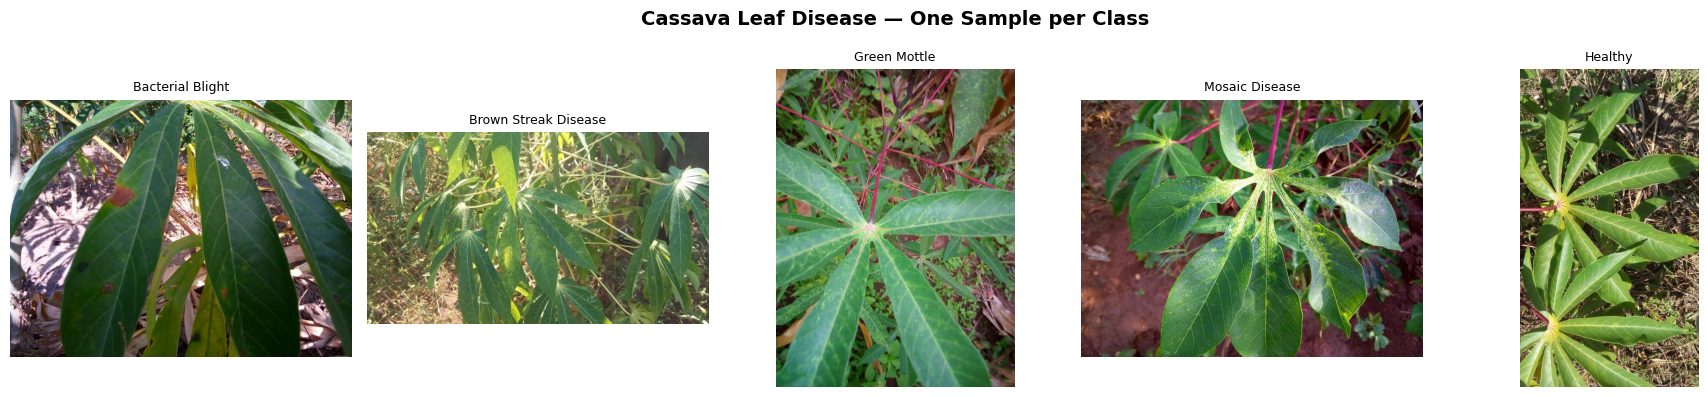

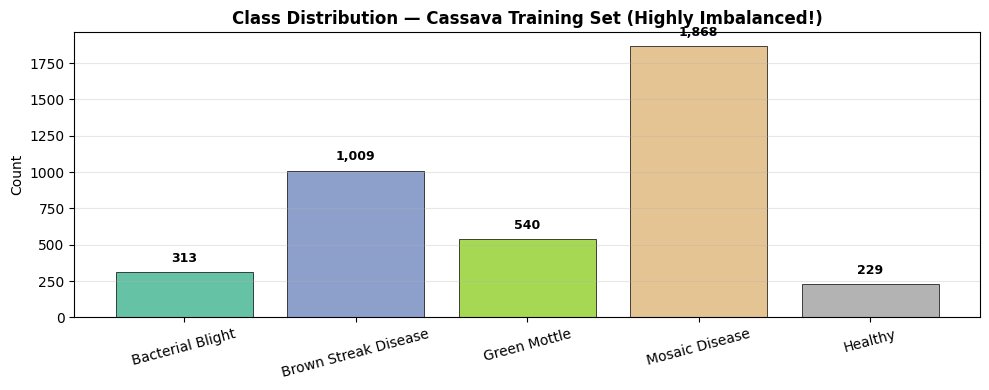

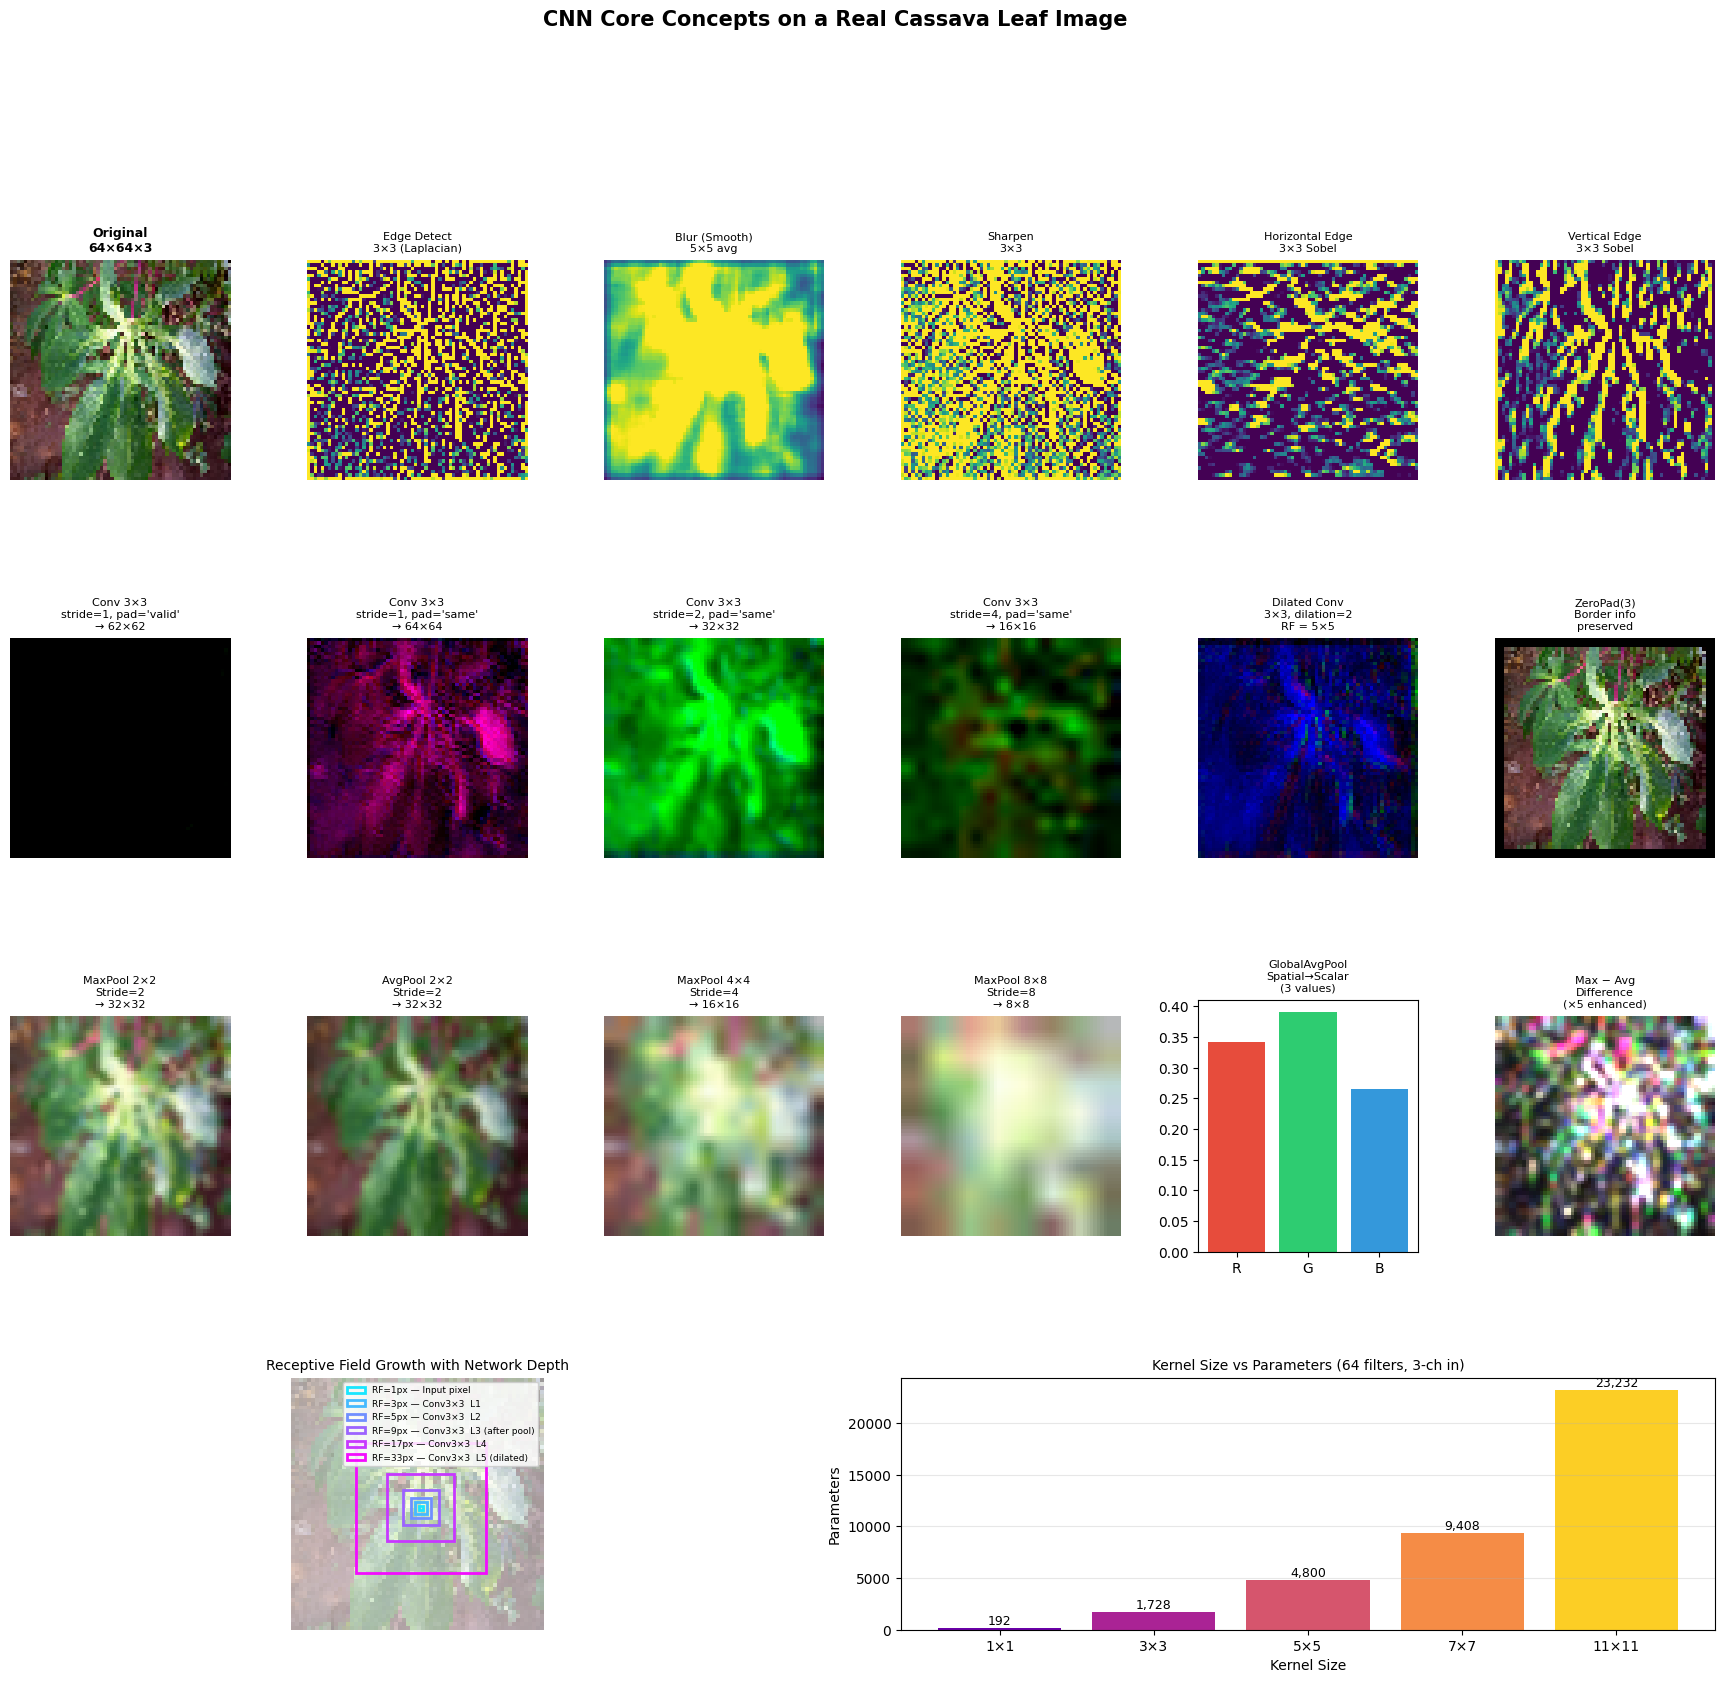

  Saved → 03_cnn_concepts.png

[5] Building data pipeline ...
  Train batches : 62  |  Val : 14  |  Test : 14

[7] Building CassavaNet ...


Model: "CassavaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)       │ (None, 64, 64, 3)    │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Stem_pad (ZeroPadding2D) │ (None, 70, 70, 3)    │            0 │ Input[0][0]           │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Stem_conv (Conv2D)       │ (None, 32, 32, 64)   │        9,408 │ Stem_pad[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Stem_bn                  │ (None, 32, 32, 64)   │          256 │ Stem_conv[0][0]       │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Stem_relu (Activation)   │ (None, 32, 32, 64)   │            0 │ Stem_bn[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ Stem_pool (MaxPooling2D) │ (None, 16, 16, 64)   │            0 │ Stem_relu[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_1_conv (Conv2D)    │ (None, 16, 16, 64)   │       36,864 │ Stem_pool[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_1_bn               │ (None, 16, 16, 64)   │          256 │ S1_B1_1_conv[0][0]    │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_1_relu             │ (None, 16, 16, 64)   │            0 │ S1_B1_1_bn[0][0]      │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_2_conv (Conv2D)    │ (None, 16, 16, 64)   │       36,864 │ S1_B1_1_relu[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_2_bn               │ (None, 16, 16, 64)   │          256 │ S1_B1_2_conv[0][0]    │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_add (Add)          │ (None, 16, 16, 64)   │            0 │ S1_B1_2_bn[0][0],     │
│                          │                      │              │ Stem_pool[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B1_out (Activation)   │ (None, 16, 16, 64)   │            0 │ S1_B1_add[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B2_1_conv (Conv2D)    │ (None, 16, 16, 64)   │       36,864 │ S1_B1_out[0][0]       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B2_1_bn               │ (None, 16, 16, 64)   │          256 │ S1_B2_1_conv[0][0]    │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B2_1_relu             │ (None, 16, 16, 64)   │            0 │ S1_B2_1_bn[0][0]      │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ S1_B2_2_conv (Conv2D)    │ (None, 16, 16, 64)   │       36,864 │ S1_B2_1_relu[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 12,043,717 (45.94 MB)

 Trainable params: 12,032,581 (45.90 MB)

 Non-trainable params: 11,136 (43.50 KB)


  Total parameters     : 12,043,717


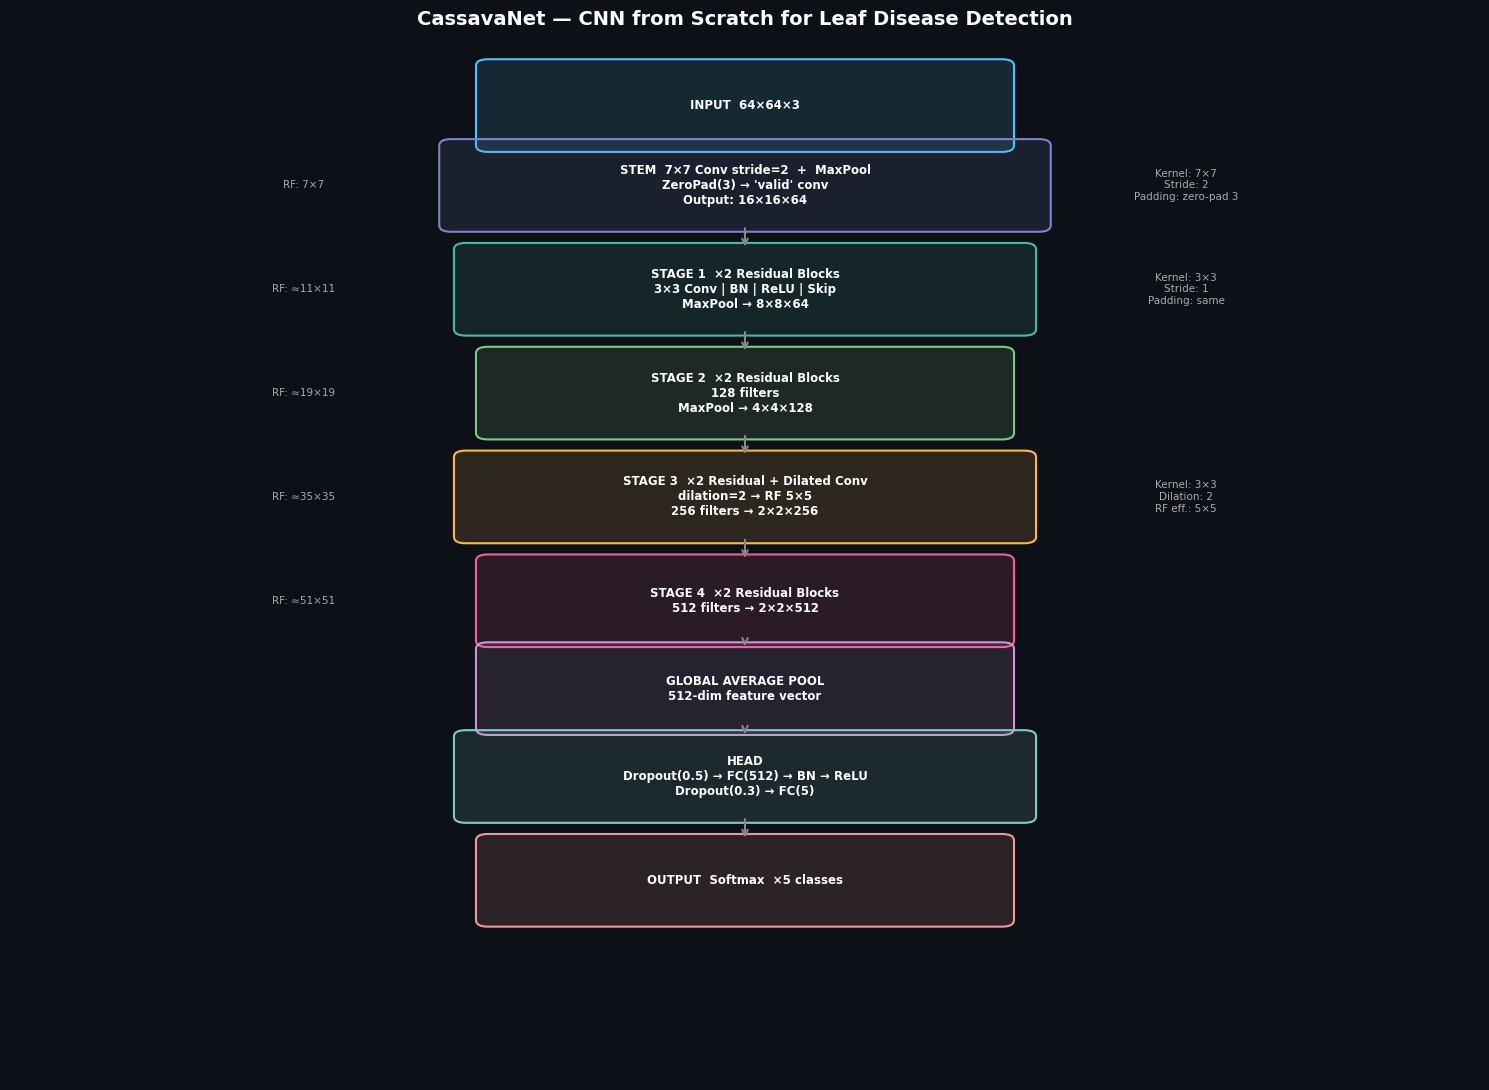

  Saved → 04_architecture.png

[9] TensorBoard log dir : logs/cnn_cassava/20260314-113149
    ► tensorboard --logdir logs/cnn_cassava

[10] Training CassavaNet ...
Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1901 - auc: 0.5011 - loss: 2.4476 - top2_acc: 0.4042
Epoch 1: val_accuracy improved from None to 0.05889, saving model to best_cnn_cassava.keras

Epoch 1: finished saving model to best_cnn_cassava.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 418s 6s/step - accuracy: 0.2038 - auc: 0.5188 - loss: 2.3707 - top2_acc: 0.4254 - val_accuracy: 0.0589 - val_auc: 0.4165 - val_loss: 16.2539 - val_top2_acc: 0.4393 - learning_rate: 9.6254e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2240 - auc: 0.5471 - loss: 2.2492 - top2_acc: 0.4573
Epoch 2: val_accuracy improved from 0.05889 to 0.12956, saving model to best_cnn_cassava.keras

Epoch 2: finished saving model to best_cnn_cassava.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.2306 - auc: 0.5624 - loss: 2

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║         CNN FROM SCRATCH — COMPLETE DEEP DIVE                       ║
# ║  Dataset : Cassava Leaf Disease (Kaggle competition, 5 classes)     ║
# ║  Covers  : Kernel · Padding · Stride · Pooling · BN                 ║
# ║            Dropout · Skip Connections · Dilated Conv · TensorBoard  ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
#  Cassava Leaf Disease Classification
#  ─────────────────────────────────────
#  • 21,397 labelled cassava leaf images (800×600, resized to 64×64)
#  • 5 classes:
#      0 — Cassava Bacterial Blight (CBB)
#      1 — Cassava Brown Streak Disease (CBSD)
#      2 — Cassava Green Mottle (CGM)
#      3 — Cassava Mosaic Disease (CMD)  ← most prevalent
#      4 — Healthy
#  • Real Kaggle competition (2020), hosted on TF/GCS → reliable download
#  • Highly imbalanced, subtle visual differences → genuinely hard
#
#  WHY THIS IS HARDER THAN CIFAR:
#   • Disease symptoms are spatially local and texture-dependent
#   • 80 %+ images are CMD; strong class imbalance must be handled
#   • Requires multi-scale feature learning (stem + deep residuals)
# ═══════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS
# ─────────────────────────────────────────────────────────────────────
import os, datetime, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, AveragePooling2D,
    GlobalAveragePooling2D, BatchNormalization, Activation,
    Dropout, Flatten, Dense, Add, ZeroPadding2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.callbacks import (
    TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow :", tf.__version__)
print("GPU        :", bool(tf.config.list_physical_devices('GPU')))

# ─────────────────────────────────────────────────────────────────────
# SECTION 1 — CONCEPT DICTIONARY  (printed for reference)
# ─────────────────────────────────────────────────────────────────────
CONCEPTS = """
╔══════════════╦══════════════════════════════════════════════════════╗
║  CONCEPT     ║  EXPLANATION                                         ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  KERNEL      ║  Learnable F×F weight matrix that slides over input. ║
║  (Filter)    ║  3×3 → fine detail | 7×7 → coarse global structure  ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  STRIDE      ║  Step size per slide. stride=1 → dense scan          ║
║              ║  stride=2 → output halved (≈ free pooling)           ║
║              ║  out = ⌊(in − F + 2P) / S⌋ + 1                     ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  PADDING     ║  'valid' → no pad, output shrinks                    ║
║              ║  'same'  → zero-pad, output = input (stride=1)       ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  POOLING     ║  MaxPool  → keeps strongest activation (textures)    ║
║              ║  AvgPool  → smooth spatial averaging                  ║
║              ║  GlobalAvgPool → entire H×W → scalar per channel     ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  DILATION    ║  Inserts gaps in kernel → expands receptive field    ║
║              ║  without extra params. dilation=2: 3×3 → RF of 5×5  ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  BATCH NORM  ║  Normalises activations per mini-batch.              ║
║              ║  Reduces internal covariate shift → faster training  ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  DROPOUT     ║  Randomly zeros p% of neurons → prevents overfitting ║
╠══════════════╬══════════════════════════════════════════════════════╣
║  SKIP CONN.  ║  F(x) + x → gradients bypass layers → deeper nets   ║
╚══════════════╩══════════════════════════════════════════════════════╝
"""
print(CONCEPTS)

# ─────────────────────────────────────────────────────────────────────
# SECTION 2 — HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────
IMG_SIZE    = 64
NUM_CLASSES = 5
BATCH_SIZE  = 64
EPOCHS      = 40
AUTOTUNE    = tf.data.AUTOTUNE

CLASS_NAMES = [
    'Bacterial Blight',
    'Brown Streak Disease',
    'Green Mottle',
    'Mosaic Disease',
    'Healthy'
]

LOG_DIR   = "logs/cnn_cassava/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
CKPT_PATH = "best_cnn_cassava.keras"

# ─────────────────────────────────────────────────────────────────────
# SECTION 3 — LOAD CASSAVA LEAF DISEASE (GCS-hosted, always works)
# ─────────────────────────────────────────────────────────────────────
print("\n[3] Loading Cassava Leaf Disease dataset ...")
print("    Source : tensorflow_datasets (GCS-hosted, no manual download)")

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    'cassava',
    split         = ['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised = True,
    with_info     = True
)

n_train = tf.data.experimental.cardinality(ds_train_raw).numpy()
n_val   = tf.data.experimental.cardinality(ds_val_raw  ).numpy()
n_test  = tf.data.experimental.cardinality(ds_test_raw ).numpy()

print(f"\n  Train : {n_train}  |  Val : {n_val}  |  Test : {n_test}")
print(f"  Classes : {NUM_CLASSES}  |  Input size : {IMG_SIZE}×{IMG_SIZE}×3")

# ── Class distribution ─────────────────────────────────────────────
label_counts = np.zeros(NUM_CLASSES, dtype=int)
for _, lbl in ds_train_raw:
    label_counts[lbl.numpy()] += 1

print("\n  Class distribution (train):")
for i, (name, cnt) in enumerate(zip(CLASS_NAMES, label_counts)):
    bar = '█' * (cnt // 100)
    print(f"    {i} {name:<22} {cnt:5d}  {bar}")

# Compute class weights for imbalance
total   = label_counts.sum()
weights = {i: total / (NUM_CLASSES * cnt) for i, cnt in enumerate(label_counts)}
print("\n  Class weights (for imbalance):")
for i, w in weights.items():
    print(f"    Class {i}: {w:.3f}")

# ── Visualise raw samples ──────────────────────────────────────────
print("\n  Plotting sample images ...")

# Collect at least one sample per class
samples_by_class = {i: None for i in range(NUM_CLASSES)}
for img, lbl in ds_train_raw:
    l = lbl.numpy()
    if samples_by_class[l] is None:
        samples_by_class[l] = img.numpy()
    if all(v is not None for v in samples_by_class.values()):
        break

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
fig.suptitle("Cassava Leaf Disease — One Sample per Class",
             fontsize=14, fontweight='bold')
for i in range(NUM_CLASSES):
    axes[i].imshow(samples_by_class[i])
    axes[i].set_title(CLASS_NAMES[i], fontsize=9, wrap=True)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('01_cassava_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Class distribution bar ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
bars   = ax.bar(CLASS_NAMES, label_counts, color=colors, edgecolor='black', lw=0.5)
for bar, cnt in zip(bars, label_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{cnt:,}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Class Distribution — Cassava Training Set (Highly Imbalanced!)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Count"); ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 4 — CNN CONCEPT VISUALISATIONS (on a real leaf image)
# ─────────────────────────────────────────────────────────────────────
def visualise_concepts(sample_img):
    img = tf.cast(
        tf.image.resize(sample_img, [64, 64]), tf.float32
    ) / 255.0
    img_batch = tf.expand_dims(img, 0)   # (1, 64, 64, 3)

    fig = plt.figure(figsize=(22, 18))
    fig.suptitle("CNN Core Concepts on a Real Cassava Leaf Image",
                 fontsize=15, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.5, wspace=0.35)

    # ── Row 0 : Original + hand-crafted kernels ────────────────────
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(img.numpy()); ax.set_title("Original\n64×64×3", fontsize=9, fontweight='bold'); ax.axis('off')

    kernels = {
        "Edge Detect\n3×3 (Laplacian)":
            np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], np.float32).reshape(3,3,1,1),
        "Blur (Smooth)\n5×5 avg":
            np.ones((5,5,1,1), np.float32)/25.0,
        "Sharpen\n3×3":
            np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], np.float32).reshape(3,3,1,1),
        "Horizontal Edge\n3×3 Sobel":
            np.array([[-1,-2,-1],[0,0,0],[1,2,1]], np.float32).reshape(3,3,1,1),
        "Vertical Edge\n3×3 Sobel":
            np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float32).reshape(3,3,1,1),
    }
    for col, (title, k) in enumerate(kernels.items(), start=1):
        k3 = np.tile(k, [1,1,3,1])
        out = tf.nn.conv2d(img_batch, k3, strides=1, padding='SAME')
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(np.clip(out[0].numpy(), 0, 1))
        ax.set_title(title, fontsize=8); ax.axis('off')

    # ── Row 1 : Stride effect ──────────────────────────────────────
    stride_info = [(1,'valid',64), (1,'same',64), (2,'same',32), (4,'same',16)]
    for col, (s, p, expected_out) in enumerate(stride_info):
        c = tf.keras.layers.Conv2D(3, 3, strides=s, padding=p, use_bias=False)
        c.build((1,64,64,3))
        out = c(img_batch)
        ax = fig.add_subplot(gs[1, col])
        ax.imshow(np.clip(tf.image.resize(out[0],[64,64]).numpy(), 0, 1))
        ax.set_title(f"Conv 3×3\nstride={s}, pad='{p}'\n→ {out.shape[1]}×{out.shape[2]}",
                     fontsize=8); ax.axis('off')

    # Dilated conv demonstration
    c_dil = tf.keras.layers.Conv2D(3, 3, dilation_rate=2, padding='same', use_bias=False)
    c_dil.build((1,64,64,3))
    out_dil = c_dil(img_batch)
    ax = fig.add_subplot(gs[1, 4])
    ax.imshow(np.clip(out_dil[0].numpy(), 0, 1))
    ax.set_title("Dilated Conv\n3×3, dilation=2\nRF = 5×5", fontsize=8); ax.axis('off')

    # Padding visualisation (pad the raw tensor)
    padded = tf.pad(img_batch, [[0,0],[3,3],[3,3],[0,0]])
    ax = fig.add_subplot(gs[1, 5])
    ax.imshow(np.clip(padded[0].numpy(), 0, 1))
    ax.set_title("ZeroPad(3)\nBorder info\npreserved", fontsize=8); ax.axis('off')

    # ── Row 2 : Pooling methods ─────────────────────────────────────
    pool_ops = [
        ("MaxPool 2×2\nStride=2\n→ 32×32",  tf.keras.layers.MaxPooling2D(2, 2)),
        ("AvgPool 2×2\nStride=2\n→ 32×32",  tf.keras.layers.AveragePooling2D(2, 2)),
        ("MaxPool 4×4\nStride=4\n→ 16×16",  tf.keras.layers.MaxPooling2D(4, 4)),
        ("MaxPool 8×8\nStride=8\n→ 8×8",    tf.keras.layers.MaxPooling2D(8, 8)),
    ]
    for col, (title, pool) in enumerate(pool_ops):
        out = pool(img_batch)
        ax = fig.add_subplot(gs[2, col])
        ax.imshow(tf.image.resize(out[0], [64,64]).numpy())
        ax.set_title(title, fontsize=8); ax.axis('off')

    # GlobalAvgPool result
    gap_val = tf.keras.layers.GlobalAveragePooling2D()(img_batch)
    ax = fig.add_subplot(gs[2, 4])
    ax.bar(['R','G','B'], gap_val[0].numpy(), color=['#e74c3c','#2ecc71','#3498db'])
    ax.set_title("GlobalAvgPool\nSpatial→Scalar\n(3 values)", fontsize=8)

    # MaxPool vs AvgPool difference image
    mp = tf.keras.layers.MaxPooling2D(2,2)(img_batch)
    ap = tf.keras.layers.AveragePooling2D(2,2)(img_batch)
    diff = tf.abs(tf.image.resize(mp,[64,64]) - tf.image.resize(ap,[64,64]))
    ax = fig.add_subplot(gs[2, 5])
    ax.imshow(diff[0].numpy() * 5, cmap='hot')
    ax.set_title("Max − Avg\nDifference\n(×5 enhanced)", fontsize=8); ax.axis('off')

    # ── Row 3 : Receptive field growth + param comparison ──────────
    ax_rf = fig.add_subplot(gs[3, :3])
    rf_data = [
        (1,  'Input pixel'),
        (3,  'Conv3×3  L1'),
        (5,  'Conv3×3  L2'),
        (9,  'Conv3×3  L3 (after pool)'),
        (17, 'Conv3×3  L4'),
        (33, 'Conv3×3  L5 (dilated)'),
    ]
    ax_rf.imshow(img.numpy(), alpha=0.4)
    center = IMG_SIZE // 2
    cmap_rf = plt.cm.cool(np.linspace(0.1, 0.95, len(rf_data)))
    for (rf, lbl), col in zip(rf_data, cmap_rf):
        rect = plt.Rectangle(
            (center-rf//2, center-rf//2), rf, rf,
            lw=2, edgecolor=col, facecolor='none', label=f"RF={rf}px — {lbl}"
        )
        ax_rf.add_patch(rect)
    ax_rf.legend(loc='upper right', fontsize=6.5, framealpha=0.85)
    ax_rf.set_title("Receptive Field Growth with Network Depth", fontsize=10)
    ax_rf.axis('off')

    ax_ks = fig.add_subplot(gs[3, 3:])
    ks = [1, 3, 5, 7, 11]
    params = [k*k*3*64 for k in ks]
    colors_ks = plt.cm.plasma(np.linspace(0.2, 0.9, len(ks)))
    bars = ax_ks.bar([f"{k}×{k}" for k in ks], params, color=colors_ks)
    for bar, p in zip(bars, params):
        ax_ks.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f"{p:,}", ha='center', va='bottom', fontsize=9)
    ax_ks.set_title("Kernel Size vs Parameters (64 filters, 3-ch in)", fontsize=10)
    ax_ks.set_xlabel("Kernel Size"); ax_ks.set_ylabel("Parameters")
    ax_ks.grid(axis='y', alpha=0.3)

    plt.savefig('03_cnn_concepts.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("  Saved → 03_cnn_concepts.png")

sample_img_for_viz, _ = next(iter(ds_train_raw.take(1)))
visualise_concepts(sample_img_for_viz)

# ─────────────────────────────────────────────────────────────────────
# SECTION 5 — DATA PIPELINE
# ─────────────────────────────────────────────────────────────────────
print("\n[5] Building data pipeline ...")

# ImageNet-style stats (good starting point for leaf images)
MEAN = tf.constant([0.485, 0.456, 0.406])
STD  = tf.constant([0.229, 0.224, 0.225])

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = (image - MEAN) / (STD + 1e-8)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def augment(image, label):
    """Aggressive augmentation — essential for leaf disease."""
    # De-normalise for pixel-space ops
    img = image * (STD + 1e-8) + MEAN
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_hue(img, 0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    # Re-normalise
    img = (img - MEAN) / (STD + 1e-8)
    return img, label

ds_train = (
    ds_train_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .shuffle(2048)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_val = (
    ds_val_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_test = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print(f"  Train batches : {len(ds_train)}  |  Val : {len(ds_val)}  |  Test : {len(ds_test)}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 6 — BUILD CNN FROM SCRATCH  ("CassavaNet")
# ─────────────────────────────────────────────────────────────────────
"""
CassavaNet Architecture
════════════════════════
Every design decision is annotated.

STEM (7×7, stride=2, pad=3)
  Why 7×7?  Large initial kernel captures coarse leaf texture at once.
  stride=2 halves spatial size cheaply before expensive deep stages.
  ZeroPad(3) → 'valid' conv gives identical result to 'same' but
               makes the receptive field origin explicit.

STAGE 1-4  (Residual Blocks)
  Each block: Conv3×3 → BN → ReLU → Conv3×3 → BN → (+shortcut) → ReLU
  • 3×3 kernels stacked → grow RF without huge param counts
  • BN after each conv → normalises activations → faster convergence
  • Skip connection → gradient highway → enables 20+ layer training

DILATED CONV (dilation=2 in Stage 3)
  Effective kernel RF = 5×5 but uses only 3×3 params.
  Critical for disease spots: captures wider spatial context cheaply.

GLOBAL AVG POOL
  Collapses H×W → vector. Much cheaper than Flatten+FC (AlexNet style).
  Also provides spatial translation invariance.

HEAD
  Dropout(0.5) before first FC → heavy regularisation (small dataset)
  Dropout(0.3) before output   → lighter regularisation
  Class imbalance handled via class_weight in model.fit

Spatial journey (64×64 input):
  Input  → 64×64×3
  Stem   → 32×32×64  (7×7 conv s=2 + MaxPool s=2 would be too much)
  Stage1 → 16×16×64
  Stage2 →  8×8×128
  Stage3 →  4×4×256  (includes dilated conv)
  Stage4 →  2×2×512
  GAP    →  512
  Output →  5
"""

def conv_bn_relu(x, filters, kernel_size=3, stride=1,
                 padding='same', dilation=1, name_prefix=''):
    x = Conv2D(
        filters, kernel_size, strides=stride, padding=padding,
        dilation_rate=dilation, use_bias=False,
        kernel_regularizer=l2(1e-4),
        name=f"{name_prefix}_conv"
    )(x)
    x = BatchNormalization(name=f"{name_prefix}_bn")(x)
    x = Activation('relu', name=f"{name_prefix}_relu")(x)
    return x


def residual_block(x, filters, stride=1, name_prefix='res'):
    """
    Standard ResNet residual block.
    ┌── shortcut (1×1 proj if shape changes) ───────────────────┐
    x → Conv3×3 → BN → ReLU → Conv3×3 → BN → Add → ReLU → out
    """
    shortcut = x

    x = conv_bn_relu(x, filters, 3, stride, 'same',
                     name_prefix=f"{name_prefix}_1")
    x = Conv2D(filters, 3, 1, 'same', use_bias=False,
               kernel_regularizer=l2(1e-4),
               name=f"{name_prefix}_2_conv")(x)
    x = BatchNormalization(name=f"{name_prefix}_2_bn")(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, stride, 'same', use_bias=False,
                          kernel_regularizer=l2(1e-4),
                          name=f"{name_prefix}_proj")(shortcut)
        shortcut = BatchNormalization(
            name=f"{name_prefix}_proj_bn")(shortcut)

    x = Add(name=f"{name_prefix}_add")([x, shortcut])
    x = Activation('relu', name=f"{name_prefix}_out")(x)
    return x


def build_cassavanet(input_shape=(64, 64, 3), num_classes=5):
    inputs = Input(shape=input_shape, name='Input')

    # ── STEM: 7×7 Conv, stride=2, explicit zero-pad ───────────────
    # out = ⌊(64 − 7 + 2×3) / 2⌋ + 1 = 32  →  32×32×64
    x = ZeroPadding2D(3, name='Stem_pad')(inputs)
    x = Conv2D(64, 7, strides=2, padding='valid', use_bias=False,
               kernel_regularizer=l2(1e-4), name='Stem_conv')(x)
    x = BatchNormalization(name='Stem_bn')(x)
    x = Activation('relu', name='Stem_relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same', name='Stem_pool')(x)
    # → 16×16×64

    # ── STAGE 1: 64 filters, 2 residual blocks ────────────────────
    # 3×3 kernels: fine-grained leaf texture and vein patterns
    x = residual_block(x, 64,  name_prefix='S1_B1')
    x = residual_block(x, 64,  name_prefix='S1_B2')
    x = MaxPooling2D(2, 2, padding='same', name='S1_pool')(x)
    # → 8×8×64

    # ── STAGE 2: 128 filters, 2 residual blocks ───────────────────
    # Double channels: learn richer disease-spot representations
    x = residual_block(x, 128, name_prefix='S2_B1')
    x = residual_block(x, 128, name_prefix='S2_B2')
    x = MaxPooling2D(2, 2, padding='same', name='S2_pool')(x)
    # → 4×4×128

    # ── STAGE 3: 256 filters + DILATED CONV ───────────────────────
    # dilation=2 → effective RF 5×5 for same param budget
    # Critical for capturing spread-out mosaic disease patterns
    x = residual_block(x, 256, name_prefix='S3_B1')
    x = residual_block(x, 256, name_prefix='S3_B2')
    x = conv_bn_relu(x, 256, 3, 1, 'same', dilation=2,
                     name_prefix='S3_Dil')
    x = MaxPooling2D(2, 2, padding='same', name='S3_pool')(x)
    # → 2×2×256

    # ── STAGE 4: 512 filters, 2 residual blocks ───────────────────
    x = residual_block(x, 512, name_prefix='S4_B1')
    x = residual_block(x, 512, name_prefix='S4_B2')
    # → 2×2×512

    # ── GLOBAL AVERAGE POOLING ────────────────────────────────────
    # H×W collapsed to 1 per channel → 512-dim feature vector
    x = GlobalAveragePooling2D(name='GAP')(x)

    # ── CLASSIFICATION HEAD ───────────────────────────────────────
    x = Dropout(0.5, name='Drop1')(x)
    x = Dense(512, use_bias=False,
              kernel_regularizer=l2(1e-4), name='FC1')(x)
    x = BatchNormalization(name='FC1_bn')(x)
    x = Activation('relu', name='FC1_relu')(x)

    x = Dropout(0.3, name='Drop2')(x)
    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='CassavaNet')


# ─────────────────────────────────────────────────────────────────────
# SECTION 7 — COMPILE
# ─────────────────────────────────────────────────────────────────────
print("\n[7] Building CassavaNet ...")
model = build_cassavanet()

# Cosine Decay with Warm Restarts
# LR oscillates: escapes sharp minima → better generalisation
lr_schedule = CosineDecayRestarts(
    initial_learning_rate = 1e-3,
    first_decay_steps     = 500,
    t_mul = 2.0, m_mul = 0.9, alpha = 1e-6
)

model.compile(
    optimizer = Adam(learning_rate=lr_schedule, weight_decay=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

model.summary(line_length=90)
print(f"\n  Total parameters     : {model.count_params():,}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 8 — ARCHITECTURE DIAGRAM
# ─────────────────────────────────────────────────────────────────────
def draw_architecture():
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')
    fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#0d1117')

    layers_cfg = [
        # (x, y, label, color, box_width)
        (5.0, 12.2, "INPUT  64×64×3",                                  "#4fc3f7", 3.5),
        (5.0, 11.2, "STEM  7×7 Conv stride=2  +  MaxPool\n"
                    "ZeroPad(3) → 'valid' conv\nOutput: 16×16×64",     "#7986cb", 4.0),
        (5.0,  9.9, "STAGE 1  ×2 Residual Blocks\n"
                    "3×3 Conv | BN | ReLU | Skip\n"
                    "MaxPool → 8×8×64",                                  "#4db6ac", 3.8),
        (5.0,  8.6, "STAGE 2  ×2 Residual Blocks\n"
                    "128 filters\nMaxPool → 4×4×128",                    "#81c784", 3.5),
        (5.0,  7.3, "STAGE 3  ×2 Residual + Dilated Conv\n"
                    "dilation=2 → RF 5×5\n256 filters → 2×2×256",       "#ffb74d", 3.8),
        (5.0,  6.0, "STAGE 4  ×2 Residual Blocks\n"
                    "512 filters → 2×2×512",                             "#f06292", 3.5),
        (5.0,  4.9, "GLOBAL AVERAGE POOL\n512-dim feature vector",       "#ce93d8", 3.5),
        (5.0,  3.8, "HEAD\nDropout(0.5) → FC(512) → BN → ReLU\n"
                    "Dropout(0.3) → FC(5)",                               "#80cbc4", 3.8),
        (5.0,  2.5, "OUTPUT  Softmax  ×5 classes",                       "#ef9a9a", 3.5),
    ]

    for x, y, text, color, w in layers_cfg:
        rect = mpatches.FancyBboxPatch(
            (x-w/2, y-0.5), w, 1.0,
            boxstyle="round,pad=0.08", lw=1.5,
            edgecolor=color, facecolor=color+'22'
        )
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold',
                multialignment='center')

    for i in range(len(layers_cfg)-1):
        y1 = layers_cfg[i][1]   - 0.5
        y2 = layers_cfg[i+1][1] + 0.5
        ax.annotate('', xy=(5, y2), xytext=(5, y1),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.5))

    # Annotations
    ann = [
        (8.0, 11.2, "Kernel: 7×7\nStride: 2\nPadding: zero-pad 3"),
        (8.0,  9.9, "Kernel: 3×3\nStride: 1\nPadding: same"),
        (8.0,  7.3, "Kernel: 3×3\nDilation: 2\nRF eff.: 5×5"),
        (2.0, 11.2, "RF: 7×7"),
        (2.0,  9.9, "RF: ≈11×11"),
        (2.0,  8.6, "RF: ≈19×19"),
        (2.0,  7.3, "RF: ≈35×35"),
        (2.0,  6.0, "RF: ≈51×51"),
    ]
    for x, y, txt in ann:
        ax.text(x, y, txt, ha='center', va='center',
                fontsize=7.5, color='#aaa', multialignment='center')

    ax.set_title("CassavaNet — CNN from Scratch for Leaf Disease Detection",
                 fontsize=14, fontweight='bold', color='white', pad=12)
    plt.tight_layout()
    plt.savefig('04_architecture.png', dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("  Saved → 04_architecture.png")

draw_architecture()

# ─────────────────────────────────────────────────────────────────────
# SECTION 9 — TENSORBOARD + CALLBACKS
# ─────────────────────────────────────────────────────────────────────
print(f"\n[9] TensorBoard log dir : {LOG_DIR}")
print("    ► tensorboard --logdir logs/cnn_cassava")

callbacks = [
    TensorBoard(
        log_dir        = LOG_DIR,
        histogram_freq = 1,      # weight distributions every epoch
        write_graph    = True,   # computation graph
        write_images   = True,   # kernel images
        update_freq    = 'epoch',
        profile_batch  = 0
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=6, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        CKPT_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

# ─────────────────────────────────────────────────────────────────────
# SECTION 10 — TRAIN (with class weights for imbalance)
# ─────────────────────────────────────────────────────────────────────
print("\n[10] Training CassavaNet ...")
print("=" * 60)

history = model.fit(
    ds_train,
    epochs          = EPOCHS,
    validation_data = ds_val,
    class_weight    = weights,   # handles CMD dominance
    callbacks       = callbacks,
    verbose         = 1
)

# ─────────────────────────────────────────────────────────────────────
# SECTION 11 — EVALUATE
# ─────────────────────────────────────────────────────────────────────
print("\n[11] Evaluating on test set ...")
results = model.evaluate(ds_test, verbose=0)
print(f"\n{'='*45}")
print(f"  Test Loss         : {results[0]:.4f}")
print(f"  Test Accuracy     : {results[1]*100:.2f}%")
print(f"  Test AUC          : {results[2]:.4f}")
print(f"  Test Top-2 Acc    : {results[3]*100:.2f}%")
print(f"{'='*45}")

# ─────────────────────────────────────────────────────────────────────
# SECTION 12 — TRAINING HISTORY PLOTS
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CassavaNet Training History — Cassava Leaf Disease",
             fontsize=14, fontweight='bold')
ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],     'b-',  lw=2, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r--', lw=2, label='Val')
axes[0].axhline(results[1], color='g', ls=':', lw=1.5, label=f'Test {results[1]:.3f}')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['loss'],     'b-',  lw=2, label='Train')
axes[1].plot(ep, history.history['val_loss'], 'r--', lw=2, label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history.history['auc'],     'b-',  lw=2, label='Train AUC')
axes[2].plot(ep, history.history['val_auc'], 'r--', lw=2, label='Val AUC')
axes[2].set_title('AUC Score'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_training_history.png', dpi=130)
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 13 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────
print("\n[13] Confusion matrix ...")
y_true_all, y_pred_all = [], []
for imgs, lbls in ds_test:
    preds = model.predict(imgs, verbose=0)
    y_true_all.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred_all.extend(np.argmax(preds,        axis=1))
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

cm     = confusion_matrix(y_true_all, y_pred_all)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix — CassavaNet", fontsize=14, fontweight='bold')

short = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
sns.heatmap(cm,     annot=True, fmt='d',    cmap='Blues',
            xticklabels=short, yticklabels=short, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_pct, annot=True, fmt='.1f',  cmap='RdYlGn',
            xticklabels=short, yticklabels=short,
            ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Row-Normalised (%)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('06_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

# ─────────────────────────────────────────────────────────────────────
# SECTION 14 — FEATURE MAP VISUALISATION
# ─────────────────────────────────────────────────────────────────────
print("\n[14] Feature maps ...")
test_img_raw, test_lbl_raw = next(iter(ds_test_raw.take(1)))
test_in = (tf.cast(tf.image.resize(test_img_raw, [64,64]), tf.float32)/255.0 - MEAN) / (STD+1e-8)
test_in = tf.expand_dims(test_in, 0)

layer_names = ['Stem_relu', 'S1_B2_out', 'S2_B2_out', 'S3_Dil_relu']
feat_model  = Model(
    inputs  = model.inputs,
    outputs = [model.get_layer(n).output for n in layer_names]
)
feature_maps = feat_model.predict(test_in, verbose=0)

fig = plt.figure(figsize=(22, 14))
fig.suptitle("Feature Maps at Different Network Depths",
             fontsize=14, fontweight='bold')

n_show = 8
stage_titles = [
    f"After STEM (7×7 Conv)\n{feature_maps[0].shape[1]}×{feature_maps[0].shape[2]}×{feature_maps[0].shape[3]}",
    f"After Stage-1 Residual\n{feature_maps[1].shape[1]}×{feature_maps[1].shape[2]}×{feature_maps[1].shape[3]}",
    f"After Stage-2 Residual\n{feature_maps[2].shape[1]}×{feature_maps[2].shape[2]}×{feature_maps[2].shape[3]}",
    f"After Stage-3 Dilated\n{feature_maps[3].shape[1]}×{feature_maps[3].shape[2]}×{feature_maps[3].shape[3]}",
]

# Row 0: original + prediction
ax0 = fig.add_subplot(5, n_show, 1)
ax0.imshow(tf.image.resize(test_img_raw, [64,64]).numpy().astype('uint8'))
true_name = CLASS_NAMES[test_lbl_raw.numpy()]
pred_name = CLASS_NAMES[np.argmax(model.predict(test_in, verbose=0)[0])]
color     = 'green' if pred_name == true_name else 'red'
ax0.set_title(f"Input\nTrue: {true_name}\nPred: {pred_name}",
              fontsize=7, color=color); ax0.axis('off')

for row, (fmap, title) in enumerate(zip(feature_maps, stage_titles)):
    for col in range(n_show):
        ax = fig.add_subplot(5, n_show, (row+1)*n_show + col + 1)
        if col < fmap.shape[-1]:
            ax.imshow(fmap[0,:,:,col], cmap='viridis', aspect='auto')
        if col == 0:
            ax.set_ylabel(title, fontsize=7, rotation=0,
                          labelpad=80, va='center')
        ax.axis('off')

plt.tight_layout()
plt.savefig('07_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 15 — PREDICTION GRID
# ─────────────────────────────────────────────────────────────────────
print("\n[15] Prediction grid ...")
raw_imgs, raw_lbls = [], []
for img, lbl in ds_test_raw.take(30):
    raw_imgs.append(tf.image.resize(img, [64,64]).numpy())
    raw_lbls.append(lbl.numpy())

batch_in = np.stack([
    ((im.astype('float32')/255.0 - MEAN.numpy()) / (STD.numpy()+1e-8))
    for im in raw_imgs
])
probs      = model.predict(batch_in, verbose=0)
pred_lbls  = np.argmax(probs, axis=1)
conf       = np.max(probs, axis=1)

fig, axes = plt.subplots(5, 6, figsize=(18, 16))
fig.suptitle("CassavaNet Predictions  (green=correct | red=wrong | conf=confidence)",
             fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(raw_imgs[i].astype('uint8'))
    true = CLASS_NAMES[raw_lbls[i]]
    pred = CLASS_NAMES[pred_lbls[i]]
    col  = 'green' if pred == true else 'red'
    ax.set_title(f"P: {pred}\nT: {true}\n{conf[i]*100:.1f}%",
                 color=col, fontsize=7, pad=3)
    ax.axis('off')
plt.tight_layout()
plt.savefig('08_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 16 — PER-CLASS ACCURACY
# ─────────────────────────────────────────────────────────────────────
per_class_acc = [
    (y_pred_all[y_true_all == c] == c).mean() * 100
    for c in range(NUM_CLASSES)
]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc,
              color=plt.cm.RdYlGn(np.array(per_class_acc)/100),
              edgecolor='black', lw=0.5)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{acc:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(np.mean(per_class_acc), color='navy', ls='--', lw=1.5,
           label=f"Mean: {np.mean(per_class_acc):.1f}%")
ax.set_ylim(0, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Test Accuracy — CassavaNet", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('09_per_class_accuracy.png', dpi=130)
plt.show()

# ─────────────────────────────────────────────────────────────────────
# SECTION 17 — SUMMARY
# ─────────────────────────────────────────────────────────────────────
print("\n" + "╔" + "═"*60 + "╗")
print("║  CASSAVANET — TRAINING COMPLETE" + " "*28 + "║")
print("╠" + "═"*60 + "╣")
print(f"║  Parameters     : {model.count_params():>12,}" + " "*26 + "║")
print(f"║  Test Accuracy  : {results[1]*100:>11.2f}%" + " "*26 + "║")
print(f"║  Test AUC       : {results[2]:>12.4f}" + " "*26 + "║")
print(f"║  Test Top-2 Acc : {results[3]*100:>11.2f}%" + " "*26 + "║")
print("╠" + "═"*60 + "╣")
print("║  Outputs:" + " "*51 + "║")
for f in ['01_cassava_samples.png       — raw dataset',
          '02_class_distribution.png    — imbalance chart',
          '03_cnn_concepts.png          — kernel/pad/stride/pool',
          '04_architecture.png          — model diagram',
          '05_training_history.png      — acc/loss/auc curves',
          '06_confusion_matrix.png      — per-class performance',
          '07_feature_maps.png          — activations by depth',
          '08_predictions.png           — sample predictions',
          '09_per_class_accuracy.png    — class bar chart',
          'best_cnn_cassava.keras       — best weights']:
    print(f"║    {f}" + " "*(55-len(f)) + "║")
print("╠" + "═"*60 + "╣")
print("║  TensorBoard: tensorboard --logdir logs/cnn_cassava" + " "*8 + "║")
print("╚" + "═"*60 + "╝")